# **Kickstarter Data**

# Libraries

In [1]:
# Libraries Download
!pip install pycountry pycountry-convert
!pip install pgmpy==0.1.20 --quiet

# Core
import pandas as pd
import numpy as np
import time
import pickle

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Country mapping
import pycountry
import pycountry_convert as pc

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)
from sklearn.utils import shuffle

# Bayesian networks (pgmpy)
from pgmpy.estimators import HillClimbSearch, BicScore, K2Score, MaximumLikelihoodEstimator, BayesianEstimator
from pgmpy.models import BayesianNetwork, BayesianModel
from pgmpy.inference import VariableElimination

# Utilities
from tqdm import tqdm
from google.colab import files, drive
import io

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.8/252.8 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 13.8 MB/s eta 0:00:00


# Data Importing

In [46]:
# Data Improting
drive.mount('/drive')
file_path = "/drive/MyDrive/kickstarter_processed.csv"
df = pd.read_csv(file_path, low_memory=False)
# uploaded = files.upload()
# filename = next(iter(uploaded))
# df = pd.read_csv(io.BytesIO(uploaded[filename]), low_memory=False)

Drive already mounted at /drive; to attempt to forcibly remount, call drive.mount("/drive", force_remount=True).


# Data Cleaning

In [3]:
# Checking Data Basics
print(df.shape)
print(df.head())
print(df.dtypes)

(331462, 199)
       Category   Subcategory        Country    Launched    Deadline   Goal  \
0       Fashion       Fashion  United States  2009-04-21  2009-05-31   1000   
1  Film & Video        Shorts  United States  2009-04-23  2009-07-20  80000   
2           Art  Illustration  United States  2009-04-24  2009-05-03     20   
3    Technology      Software  United States  2009-04-25  2009-07-14     99   
4       Fashion       Fashion  United States  2009-04-27  2009-05-26   1900   

        State  Duration  Season  Goal_per_day  ...  Subcategory_Zines  \
0      Failed        40  Spring     25.000000  ...              False   
1      Failed        88  Spring    909.090909  ...              False   
2  Successful         9  Spring      2.222222  ...              False   
3  Successful        80  Spring      1.237500  ...              False   
4      Failed        29  Spring     65.517241  ...              False   

  Region_Asia  Region_Europe Region_North America  Region_Oceania  \
0  

In [4]:
df['State'] = df['State'].astype(str).str.strip()
df = df[df['State'].isin(['Successful', 'Failed'])].copy()
for col in ['Launched', 'Deadline']:
    df[col] = pd.to_datetime(df[col], errors='coerce').dt.date

print("Rows after filtering:", df.shape[0])
print(df['State'].value_counts())

Rows after filtering: 331462
State
Failed        197611
Successful    133851
Name: count, dtype: int64


In [ ]:
df['Launched'] = pd.to_datetime(df['Launched'], errors='coerce')
df['Deadline'] = pd.to_datetime(df['Deadline'], errors='coerce')

df = df.dropna(subset=['Launched','Deadline']).copy()

df['Duration'] = (df['Deadline'] - df['Launched']).dt.days
df = df[df['Duration'] > 0].copy()

def get_season(date):
    Y = date.year
    seasons = {
        'Spring': (pd.Timestamp(f"{Y}-03-21"), pd.Timestamp(f"{Y}-06-20")),
        'Summer': (pd.Timestamp(f"{Y}-06-21"), pd.Timestamp(f"{Y}-09-22")),
        'Autumn': (pd.Timestamp(f"{Y}-09-23"), pd.Timestamp(f"{Y}-12-20")),
        'Winter': (pd.Timestamp(f"{Y}-12-21"), pd.Timestamp(f"{Y}-12-31")),
    }
    if date.month == 1 or (date.month == 2 and date.day <= 28) or (date.month == 3 and date.day < 21):
        return "Winter"
    for season, (start, end) in seasons.items():
        if start <= date <= end:
            return season
    return "Winter"

def majority_season(row):
    days = pd.date_range(start=row['Launched'], end=row['Deadline'])
    season_counts = days.to_series().apply(get_season).value_counts()
    return season_counts.idxmax()

df['Season'] = df.apply(majority_season, axis=1)
df['Goal_per_day'] = df['Goal'] / df['Duration']

In [ ]:
df = df.drop(columns=['ID','Name','Pledged','Backers'])
df['US_vs_nonUS'] = np.where(df['Country']=='United States', 1, 0)

In [ ]:
def country_to_continent(country_name):
    try:
        country_alpha2 = pycountry.countries.lookup(country_name).alpha_2
        continent_name = pc.country_alpha2_to_continent_code(country_alpha2)
        continent_dict = {'NA':'North America','SA':'South America','EU':'Europe',
                          'AS':'Asia','AF':'Africa','OC':'Oceania','AN':'Antarctica'}
        return continent_dict.get(continent_name,'Other')
    except:
        return 'Other'

df['Region'] = df['Country'].apply(country_to_continent)

In [ ]:
print(df[['Launched','Deadline','Duration','Season','Goal','Goal_per_day']].head())
print(df.dtypes)
print(df.describe(include="all"))

    Launched   Deadline  Duration  Season   Goal  Goal_per_day
0 2009-04-21 2009-05-31        40  Spring   1000     25.000000
1 2009-04-23 2009-07-20        88  Spring  80000    909.090909
2 2009-04-24 2009-05-03         9  Spring     20      2.222222
3 2009-04-25 2009-07-14        80  Spring     99      1.237500
4 2009-04-27 2009-05-26        29  Spring   1900     65.517241
Category                object
Subcategory             object
Country                 object
Launched        datetime64[ns]
Deadline        datetime64[ns]
Goal                     int64
State                   object
Duration                 int64
Season                  object
Goal_per_day           float64
US_vs_nonUS              int64
Region                  object
dtype: object
            Category     Subcategory        Country  \
count         331462          331462         331462   
unique            15             159             22   
top     Film & Video  Product Design  United States   
freq           5

In [ ]:
def detect_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    return series[(series < lower) | (series > upper)]

for state in df['State'].unique():
    outliers = detect_outliers(df[df['State']==state]['Goal'])
    print(f"State: {state}, Outliers in Goal: {len(outliers)}")


State: Failed, Outliers in Goal: 25338
State: Successful, Outliers in Goal: 12276


# Basics Plots & Theme Configuration

In [ ]:
# Plots Configurations
kickstarter_colors = ["#00B386", "#FF5A36"]
sns.set_style("whitegrid")
sns.set_palette(kickstarter_colors)
plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14

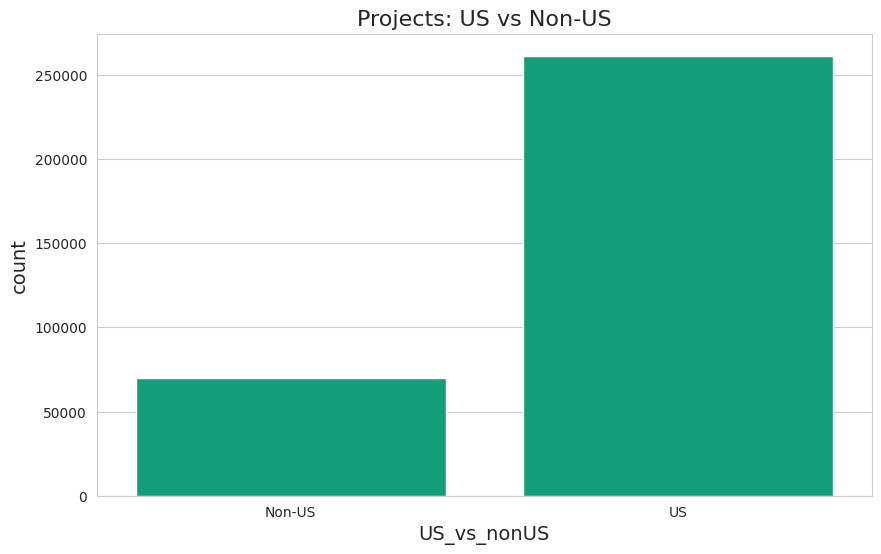

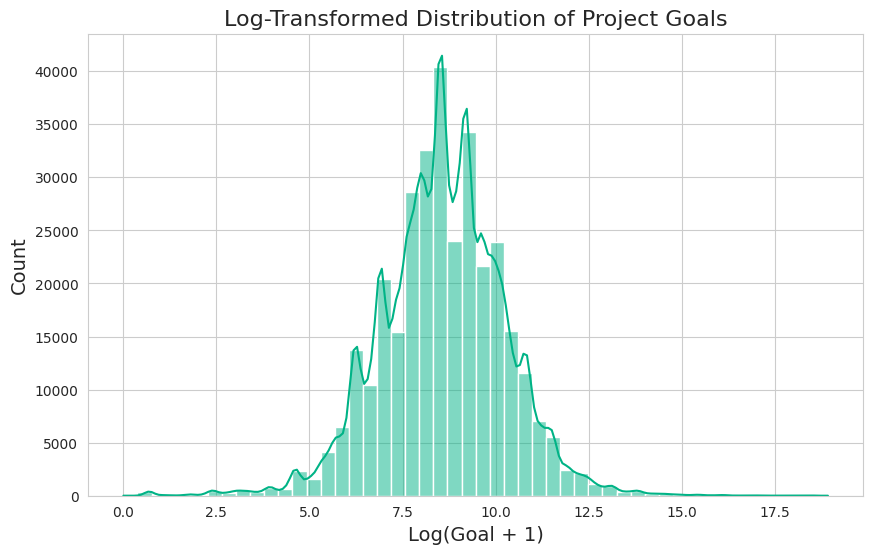

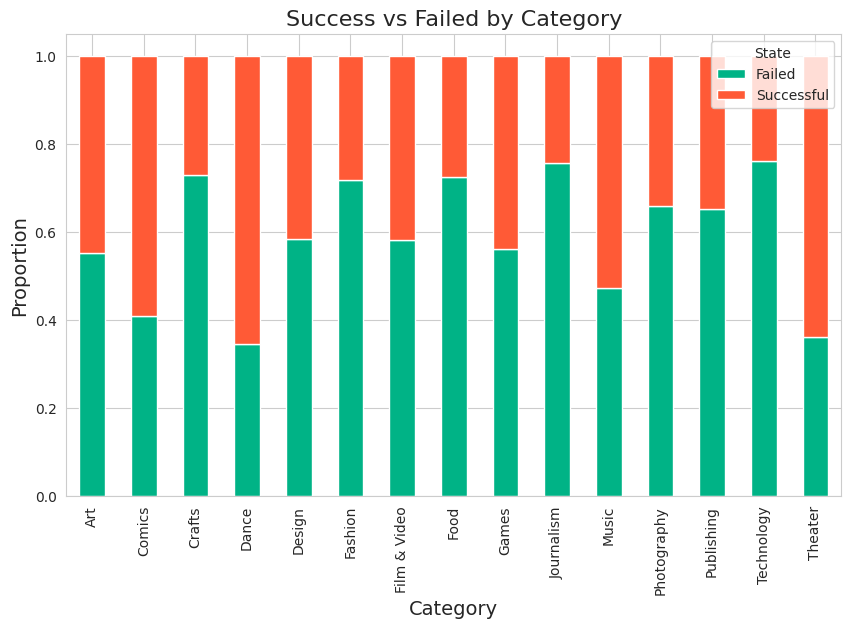

/tmp/ipython-input-2528099803.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Subcategory', data=df[df['Subcategory'].isin(top_subcats)],
/tmp/ipython-input-2528099803.py:27: UserWarning: 
The palette list has fewer values (2) than needed (20) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(y='Subcategory', data=df[df['Subcategory'].isin(top_subcats)],


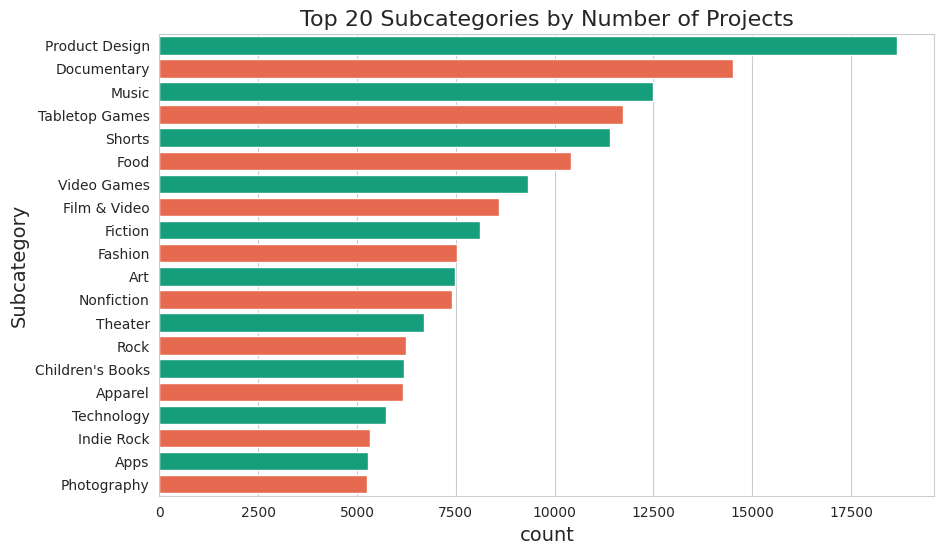

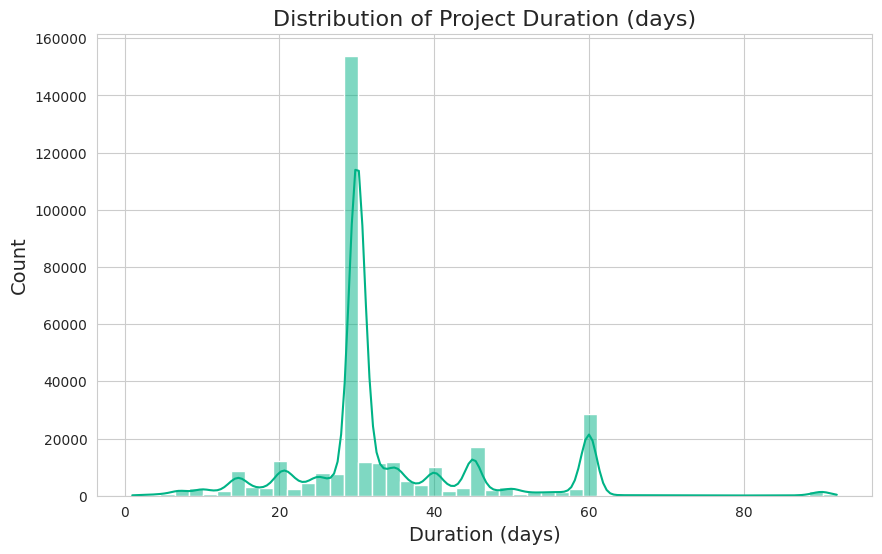

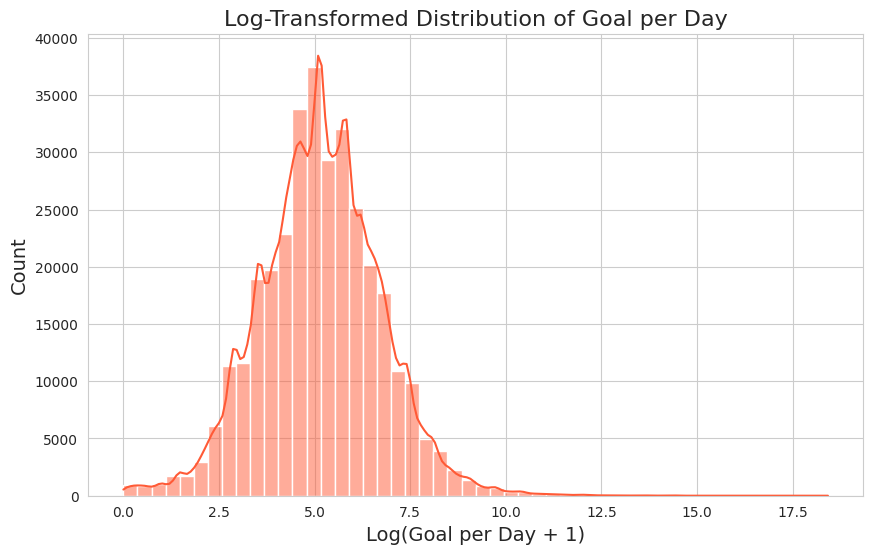

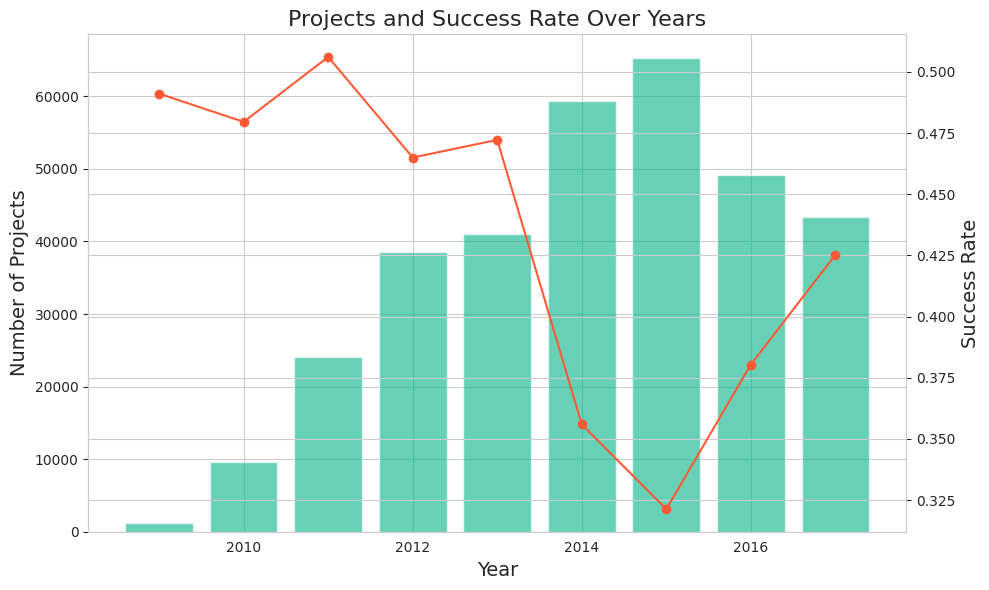

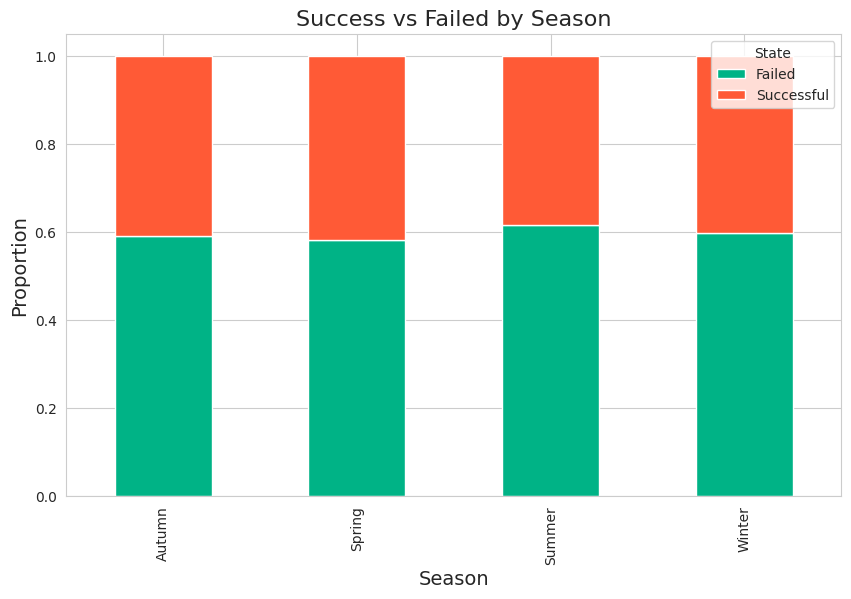

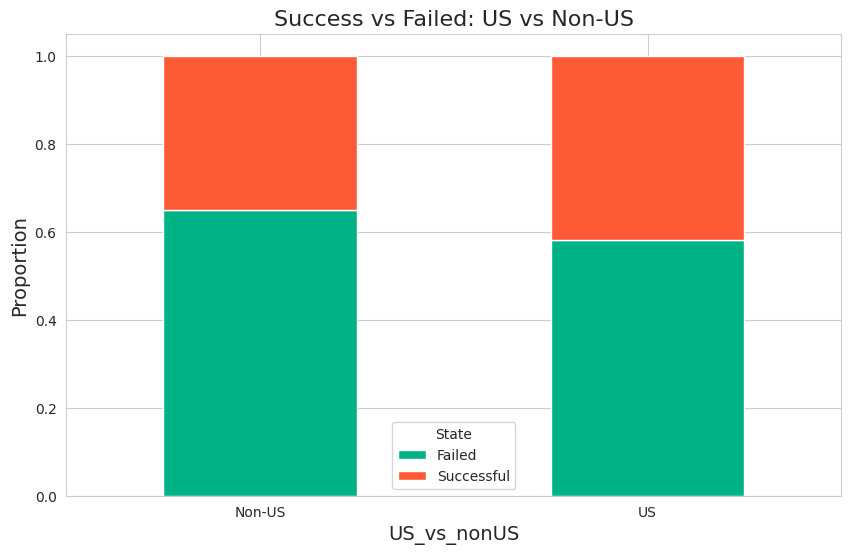

In [ ]:
# US vs Non-US distribution
sns.countplot(x='US_vs_nonUS', data=df)
plt.xticks([0,1], ['Non-US','US'])
plt.title("Projects: US vs Non-US")
plt.show()

# Distribution of Goals (log scale)
sns.histplot(np.log1p(df['Goal']), bins=50, kde=True, color=kickstarter_colors[0])
plt.title("Log-Transformed Distribution of Project Goals")
plt.xlabel("Log(Goal + 1)")
plt.ylabel("Count")
plt.show()

# Category distribution with success rate
category_success = df.groupby('Category')['State'].value_counts(normalize=True).unstack()
category_success.plot(kind='bar', stacked=True, color=kickstarter_colors)
plt.title("Success vs Failed by Category")
plt.ylabel("Proportion")
plt.show()

# 4) Top 20 Subcategory distribution
top_subcats = df['Subcategory'].value_counts().head(20).index
sns.countplot(y='Subcategory', data=df[df['Subcategory'].isin(top_subcats)],
              order=top_subcats, palette=kickstarter_colors)
plt.title("Top 20 Subcategories by Number of Projects")
plt.show()

# 5) Duration distribution
sns.histplot(df['Duration'], bins=50, kde=True, color=kickstarter_colors[0])
plt.title("Distribution of Project Duration (days)")
plt.xlabel("Duration (days)")
plt.ylabel("Count")
plt.show()

# 6) Goal per day distribution (log scale)
sns.histplot(np.log1p(df['Goal_per_day']), bins=50, kde=True, color=kickstarter_colors[1])
plt.title("Log-Transformed Distribution of Goal per Day")
plt.xlabel("Log(Goal per Day + 1)")
plt.ylabel("Count")
plt.show()

# 7) Trend over Years (projects launched)
df['Launch_Year'] = df['Launched'].dt.year
yearly_projects = df.groupby('Launch_Year').size()
yearly_success_rate = df[df['State']=='Successful'].groupby('Launch_Year').size() / yearly_projects

fig, ax1 = plt.subplots()
ax1.bar(yearly_projects.index, yearly_projects.values, color=kickstarter_colors[0], alpha=0.6, label="Total Projects")
ax1.set_ylabel("Number of Projects")
ax2 = ax1.twinx()
ax2.plot(yearly_success_rate.index, yearly_success_rate.values, color=kickstarter_colors[1], marker='o', label="Success Rate")
ax2.set_ylabel("Success Rate")
ax1.set_xlabel("Year")
plt.title("Projects and Success Rate Over Years")
fig.tight_layout()
plt.show()

# 8) Season-wise success/failure
season_success = df.groupby('Season')['State'].value_counts(normalize=True).unstack()
season_success.plot(kind='bar', stacked=True, color=kickstarter_colors)
plt.title("Success vs Failed by Season")
plt.ylabel("Proportion")
plt.show()

# 9) US vs Non-US success rate
us_success = df.groupby('US_vs_nonUS')['State'].value_counts(normalize=True).unstack()
us_success.plot(kind='bar', stacked=True, color=kickstarter_colors)
plt.title("Success vs Failed: US vs Non-US")
plt.ylabel("Proportion")
plt.xticks([0,1], ['Non-US','US'], rotation=0)
plt.show()

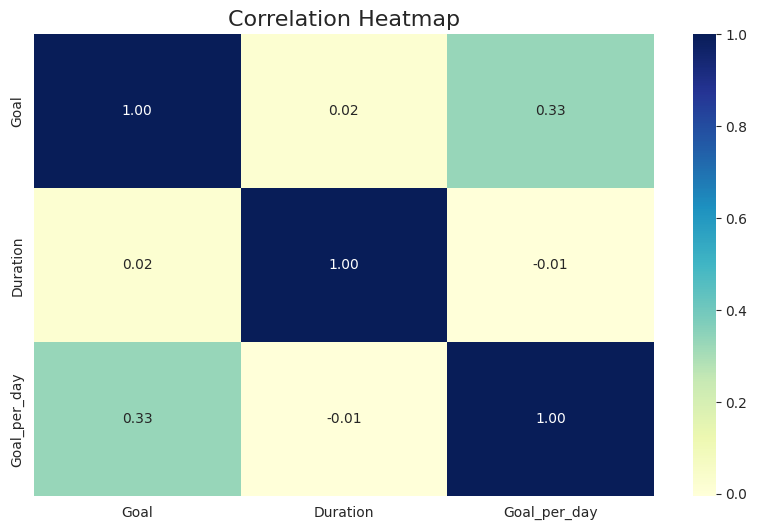

/tmp/ipython-input-461745430.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y=np.log1p(df['Goal']), data=df, palette=kickstarter_colors)
/tmp/ipython-input-461745430.py:11: UserWarning: 
The palette list has fewer values (2) than needed (15) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(x='Category', y=np.log1p(df['Goal']), data=df, palette=kickstarter_colors)


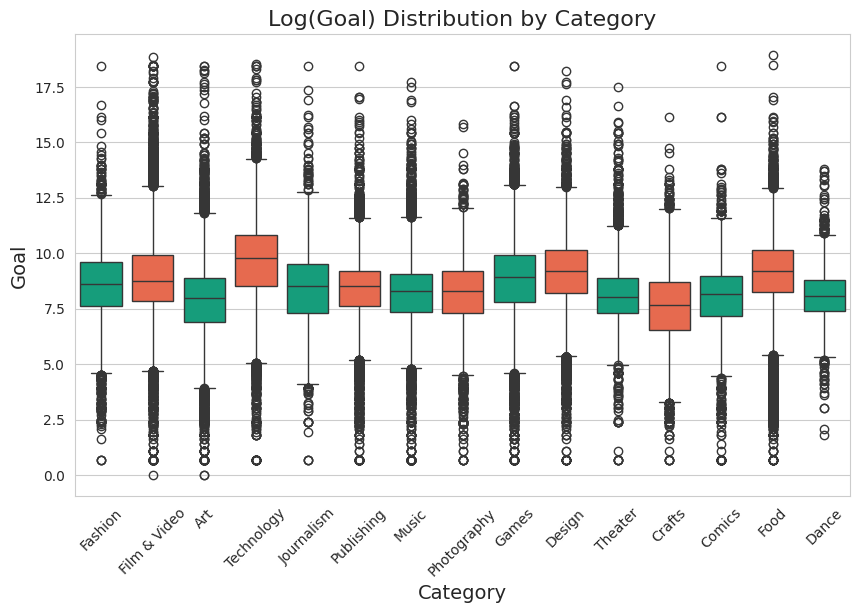

/tmp/ipython-input-461745430.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y=np.log1p(df['Goal_per_day']), data=df, palette=kickstarter_colors)
/tmp/ipython-input-461745430.py:16: UserWarning: 
The palette list has fewer values (2) than needed (15) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(x='Category', y=np.log1p(df['Goal_per_day']), data=df, palette=kickstarter_colors)


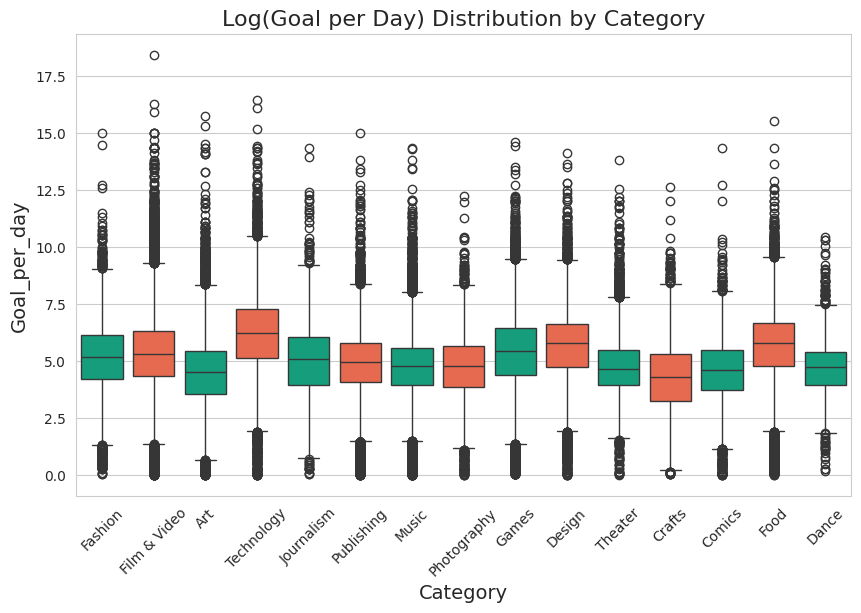

/tmp/ipython-input-461745430.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Season', y=np.log1p(df['Goal']), data=df, palette=kickstarter_colors)
/tmp/ipython-input-461745430.py:23: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(x='Season', y=np.log1p(df['Goal']), data=df, palette=kickstarter_colors)


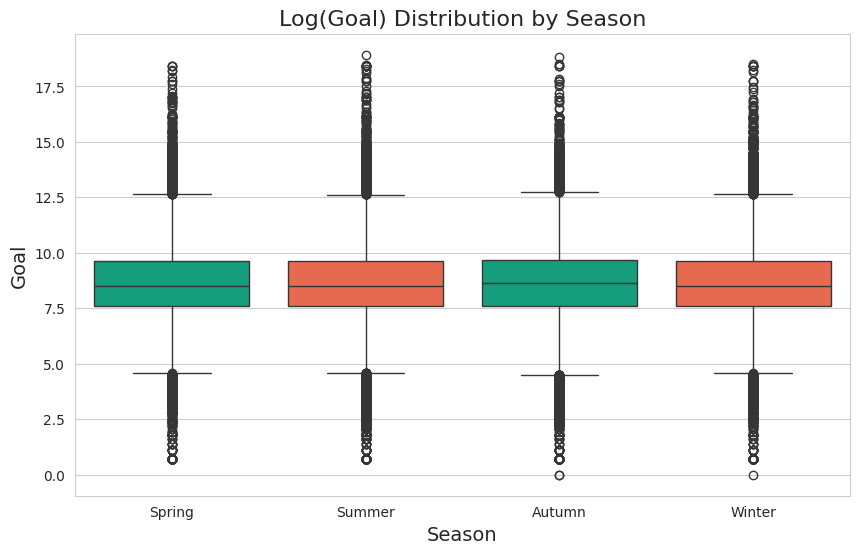

/tmp/ipython-input-461745430.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Season', y=np.log1p(df['Goal_per_day']), data=df, palette=kickstarter_colors)
/tmp/ipython-input-461745430.py:27: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(x='Season', y=np.log1p(df['Goal_per_day']), data=df, palette=kickstarter_colors)


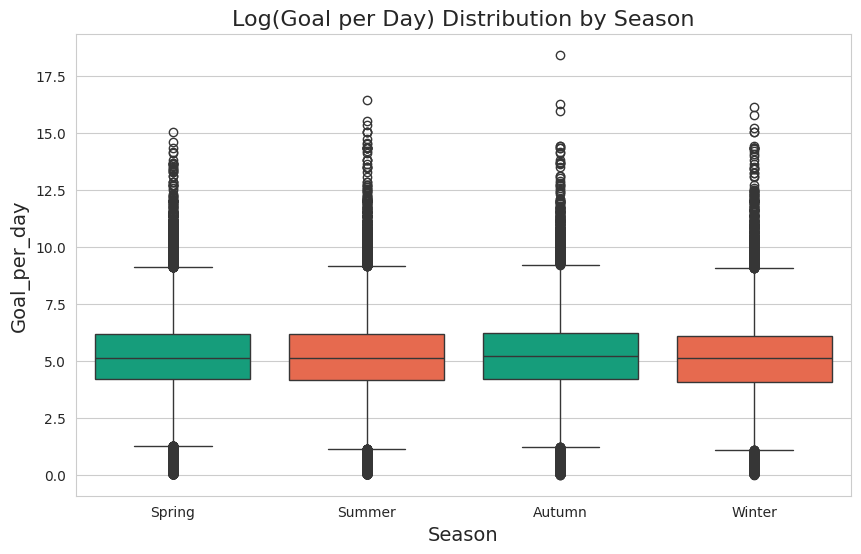

/tmp/ipython-input-461745430.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=subcat_rates['Success'], y=subcat_rates.index, palette=kickstarter_colors)
/tmp/ipython-input-461745430.py:40: UserWarning: 
The palette list has fewer values (2) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=subcat_rates['Success'], y=subcat_rates.index, palette=kickstarter_colors)


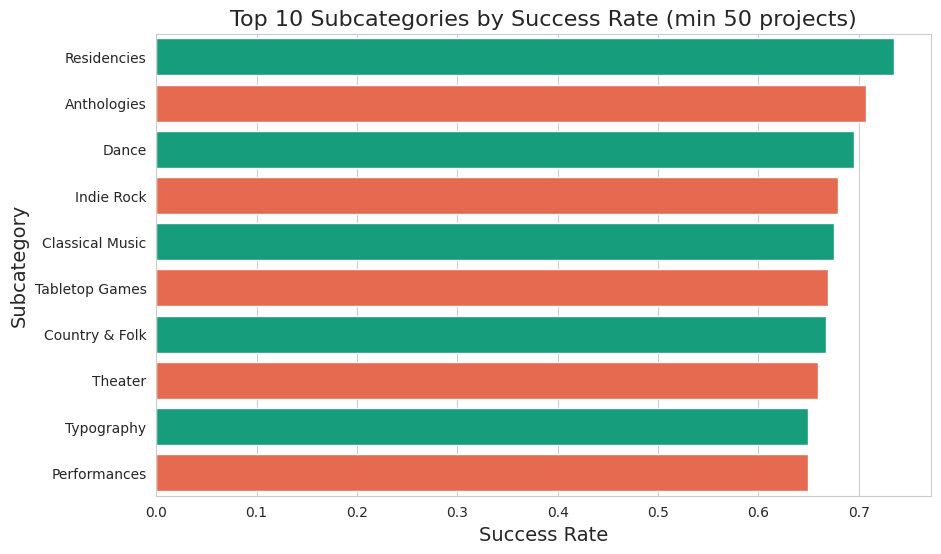

/tmp/ipython-input-461745430.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_rates['Success'], y=cat_rates.index, palette=kickstarter_colors)
/tmp/ipython-input-461745430.py:48: UserWarning: 
The palette list has fewer values (2) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=cat_rates['Success'], y=cat_rates.index, palette=kickstarter_colors)


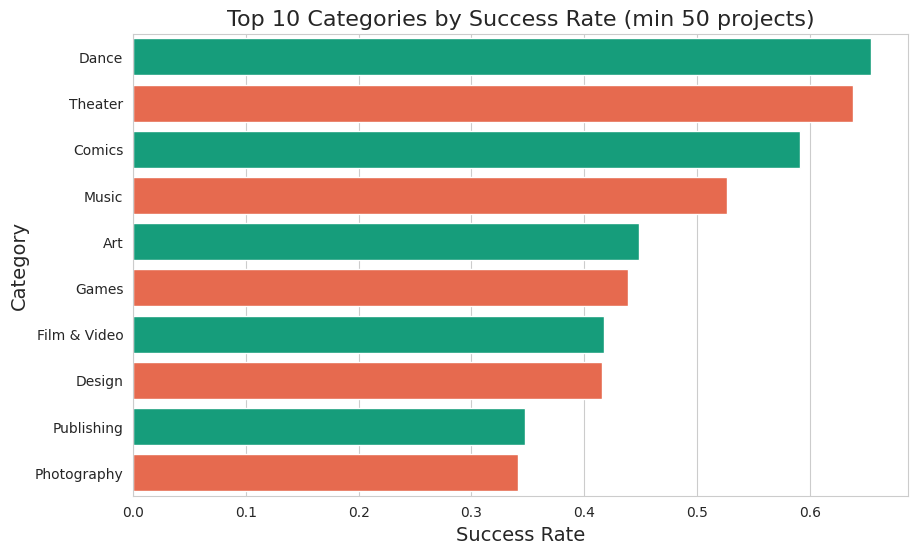

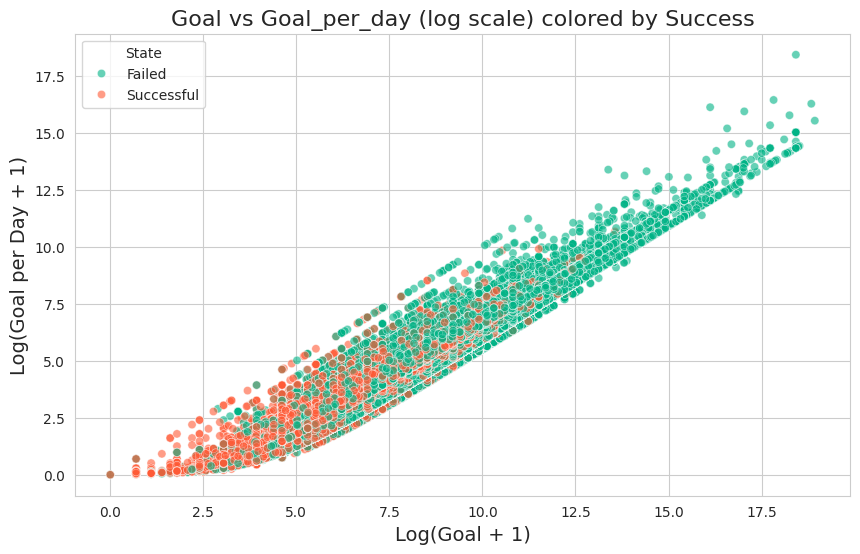

In [ ]:
# Correlation heatmap: Goal, Duration, Goal_per_day
corr_cols = ['Goal','Duration','Goal_per_day']
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Correlation Heatmap")
plt.show()

# Boxplots of Goal / Goal_per_day by Category
sns.boxplot(x='Category', y=np.log1p(df['Goal']), data=df, palette=kickstarter_colors)
plt.xticks(rotation=45)
plt.title("Log(Goal) Distribution by Category")
plt.show()

sns.boxplot(x='Category', y=np.log1p(df['Goal_per_day']), data=df, palette=kickstarter_colors)
plt.xticks(rotation=45)
plt.title("Log(Goal per Day) Distribution by Category")
plt.show()

# Boxplots of Goal / Goal_per_day by Season
sns.boxplot(x='Season', y=np.log1p(df['Goal']), data=df, palette=kickstarter_colors)
plt.title("Log(Goal) Distribution by Season")
plt.show()

sns.boxplot(x='Season', y=np.log1p(df['Goal_per_day']), data=df, palette=kickstarter_colors)
plt.title("Log(Goal per Day) Distribution by Season")
plt.show()

# Top 10 most successful subcategories and categories (Calculate success rate)
df_success = df.copy()
df_success['Success'] = (df_success['State'] == 'Successful').astype(int)

# Top 10 Subcategories by success rate (with at least 50 projects)
subcat_rates = df_success.groupby('Subcategory').agg({'Success':'mean', 'State':'count'})
subcat_rates = subcat_rates[subcat_rates['State']>=50].sort_values('Success', ascending=False).head(10)
sns.barplot(x=subcat_rates['Success'], y=subcat_rates.index, palette=kickstarter_colors)
plt.xlabel("Success Rate")
plt.title("Top 10 Subcategories by Success Rate (min 50 projects)")
plt.show()

# Top 10 Categories by success rate
cat_rates = df_success.groupby('Category').agg({'Success':'mean', 'State':'count'})
cat_rates = cat_rates[cat_rates['State']>=50].sort_values('Success', ascending=False).head(10)
sns.barplot(x=cat_rates['Success'], y=cat_rates.index, palette=kickstarter_colors)
plt.xlabel("Success Rate")
plt.title("Top 10 Categories by Success Rate (min 50 projects)")
plt.show()

# Scatter: Goal vs Goal_per_day colored by Success
sns.scatterplot(x=np.log1p(df['Goal']), y=np.log1p(df['Goal_per_day']),
                hue=df['State'], palette=kickstarter_colors, alpha=0.6)
plt.title("Goal vs Goal_per_day (log scale) colored by Success")
plt.xlabel("Log(Goal + 1)")
plt.ylabel("Log(Goal per Day + 1)")
plt.legend(title='State')
plt.show()

/tmp/ipython-input-1603983613.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Category', y=np.log1p(df['Goal']), data=df, palette=kickstarter_colors)
/tmp/ipython-input-1603983613.py:2: UserWarning: 
The palette list has fewer values (2) than needed (15) and will cycle, which may produce an uninterpretable plot.
  sns.violinplot(x='Category', y=np.log1p(df['Goal']), data=df, palette=kickstarter_colors)


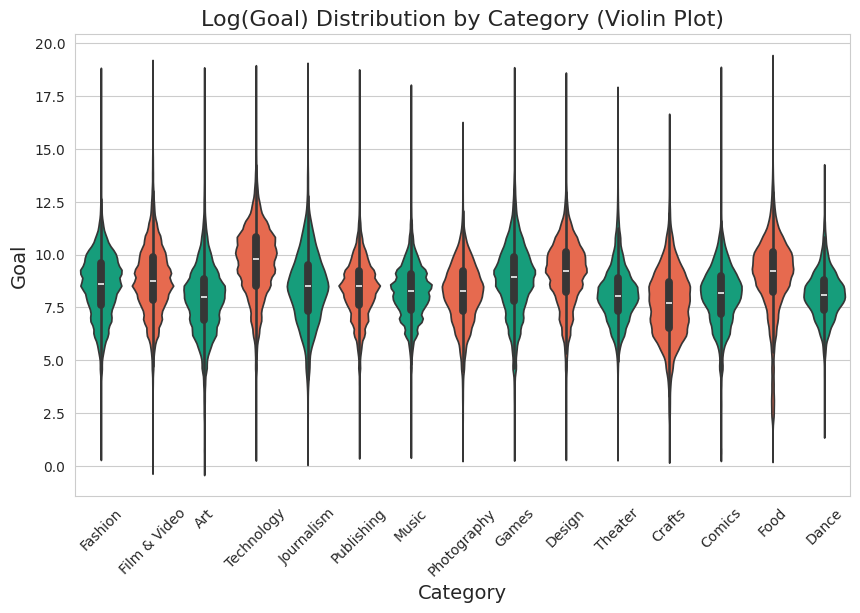

/tmp/ipython-input-1603983613.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Category', y=np.log1p(df['Goal_per_day']), data=df, palette=kickstarter_colors)
/tmp/ipython-input-1603983613.py:7: UserWarning: 
The palette list has fewer values (2) than needed (15) and will cycle, which may produce an uninterpretable plot.
  sns.violinplot(x='Category', y=np.log1p(df['Goal_per_day']), data=df, palette=kickstarter_colors)


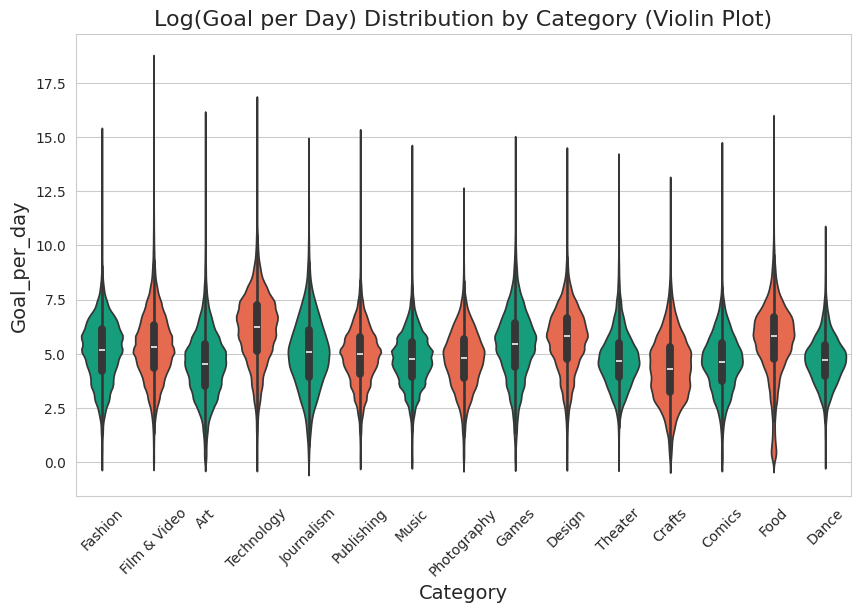

/tmp/ipython-input-1603983613.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Season', y=np.log1p(df['Goal']), data=df, palette=kickstarter_colors)
/tmp/ipython-input-1603983613.py:13: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.violinplot(x='Season', y=np.log1p(df['Goal']), data=df, palette=kickstarter_colors)


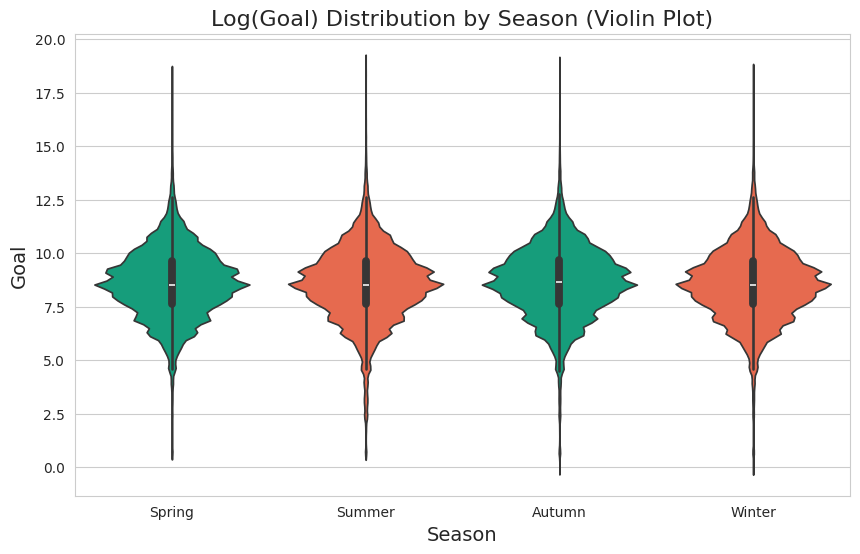

/tmp/ipython-input-1603983613.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Season', y=np.log1p(df['Goal_per_day']), data=df, palette=kickstarter_colors)
/tmp/ipython-input-1603983613.py:17: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.violinplot(x='Season', y=np.log1p(df['Goal_per_day']), data=df, palette=kickstarter_colors)


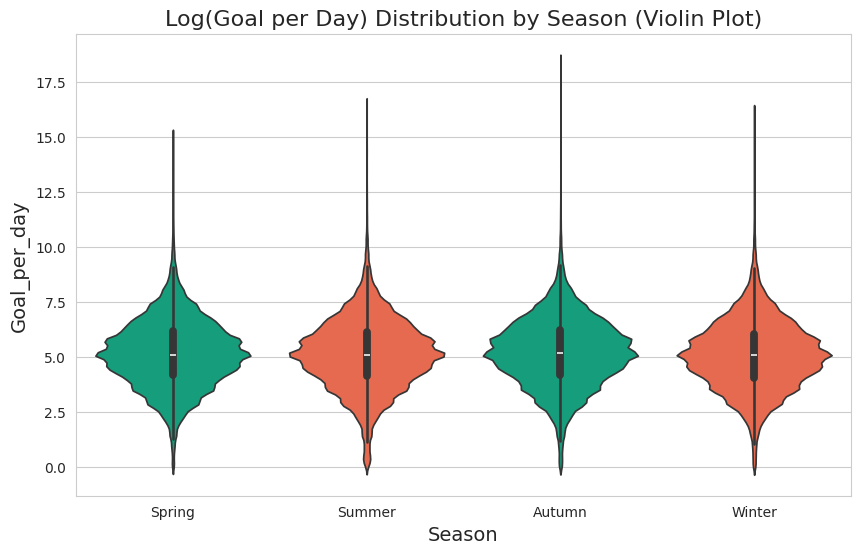

In [ ]:
# Violin plots for Goal and Goal_per_day by Category
sns.violinplot(x='Category', y=np.log1p(df['Goal']), data=df, palette=kickstarter_colors)
plt.xticks(rotation=45)
plt.title("Log(Goal) Distribution by Category (Violin Plot)")
plt.show()

sns.violinplot(x='Category', y=np.log1p(df['Goal_per_day']), data=df, palette=kickstarter_colors)
plt.xticks(rotation=45)
plt.title("Log(Goal per Day) Distribution by Category (Violin Plot)")
plt.show()

# Violin plots for Goal and Goal_per_day by Season
sns.violinplot(x='Season', y=np.log1p(df['Goal']), data=df, palette=kickstarter_colors)
plt.title("Log(Goal) Distribution by Season (Violin Plot)")
plt.show()

sns.violinplot(x='Season', y=np.log1p(df['Goal_per_day']), data=df, palette=kickstarter_colors)
plt.title("Log(Goal per Day) Distribution by Season (Violin Plot)")
plt.show()

/tmp/ipython-input-155459879.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_success.values, y=region_success.index, palette=kickstarter_colors)
/tmp/ipython-input-155459879.py:5: UserWarning: 
The palette list has fewer values (2) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=region_success.values, y=region_success.index, palette=kickstarter_colors)


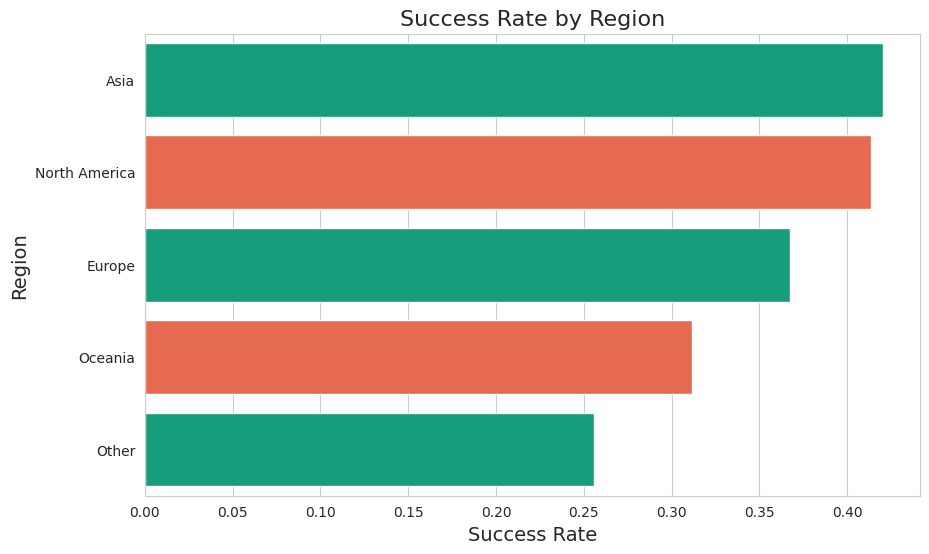

/tmp/ipython-input-155459879.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=us_success.index, y=us_success.values, palette=kickstarter_colors)


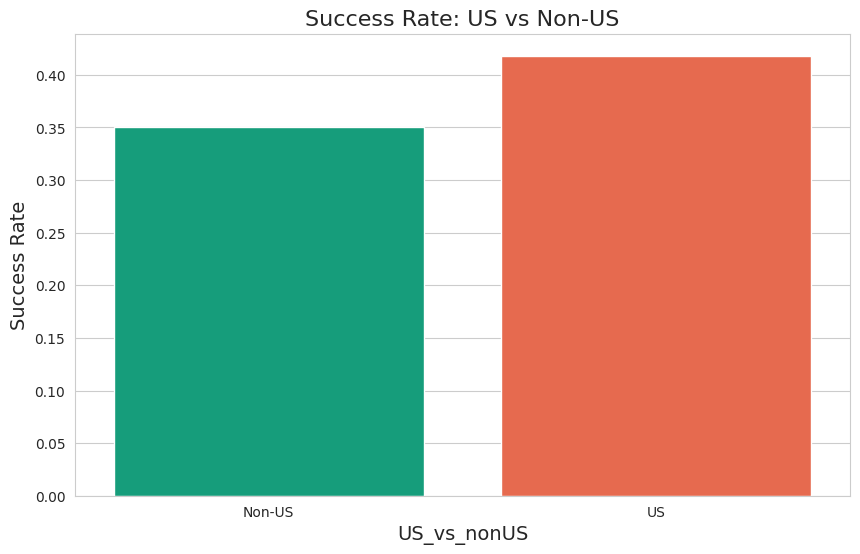

In [ ]:
# Success rate by Region
df_success = df.copy()
df_success['Success'] = (df_success['State'] == 'Successful').astype(int)
region_success = df_success.groupby('Region')['Success'].mean().sort_values(ascending=False)

sns.barplot(x=region_success.values, y=region_success.index, palette=kickstarter_colors)
plt.xlabel("Success Rate")
plt.title("Success Rate by Region")
plt.show()

# Success rate by US vs Non-US
us_success = df_success.groupby('US_vs_nonUS')['Success'].mean()
sns.barplot(x=us_success.index, y=us_success.values, palette=kickstarter_colors)
plt.xticks([0,1], ['Non-US','US'])
plt.ylabel("Success Rate")
plt.title("Success Rate: US vs Non-US")
plt.show()

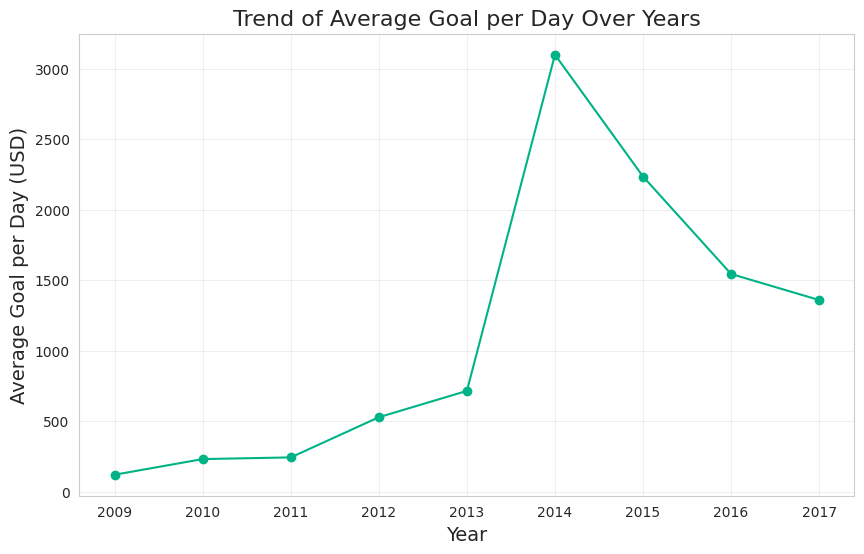

In [ ]:
# Average Goal_per_day per Year
df['Launch_Year'] = df['Launched'].dt.year
avg_goal_per_day = df.groupby('Launch_Year')['Goal_per_day'].mean()

plt.plot(avg_goal_per_day.index, avg_goal_per_day.values, marker='o', color=kickstarter_colors[0])
plt.xlabel("Year")
plt.ylabel("Average Goal per Day (USD)")
plt.title("Trend of Average Goal per Day Over Years")
plt.grid(alpha=0.3)
plt.show()

/tmp/ipython-input-386446230.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  goal_success = df.groupby('Goal_bin', observed=True).apply(lambda x: (x['State']=='Successful').mean())


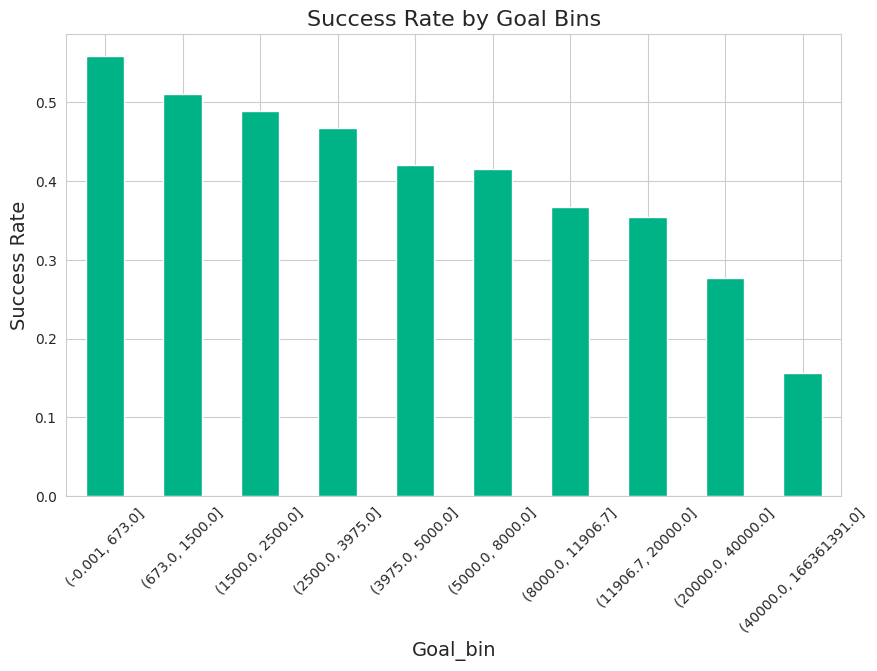

In [ ]:
# Success rate per Goal bin using a condition
df['Goal_bin'] = pd.qcut(df['Goal'], 10)
goal_success = df.groupby('Goal_bin', observed=True).apply(lambda x: (x['State']=='Successful').mean())

goal_success.plot(kind='bar', color=kickstarter_colors[0])
plt.ylabel("Success Rate")
plt.title("Success Rate by Goal Bins")
plt.xticks(rotation=45)
plt.show()

/tmp/ipython-input-3826866150.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  season_region = df.groupby(['Season','Region'], observed=True).apply(


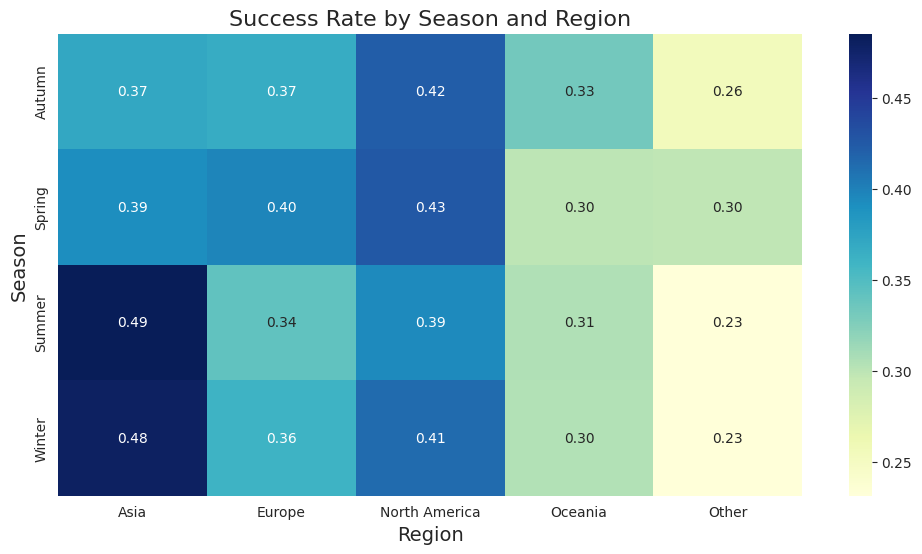

/tmp/ipython-input-3826866150.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cat_sub_success = df.groupby(['Category','Subcategory'], observed=True).apply(


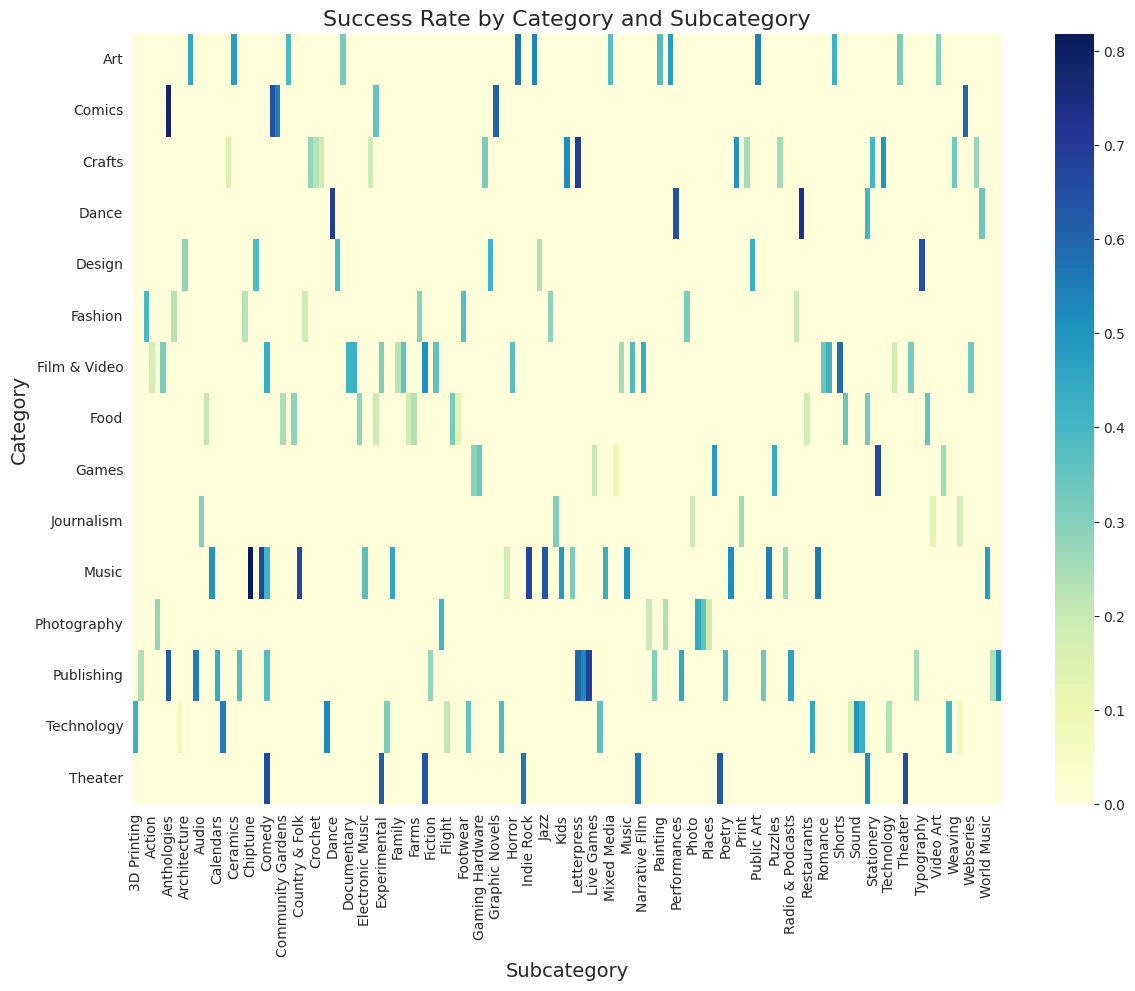

In [ ]:
# Success rate by Season and Region
season_region = df.groupby(['Season','Region'], observed=True).apply(
    lambda x: (x['State']=='Successful').mean()
).unstack()

plt.figure(figsize=(12,6))
sns.heatmap(season_region, cmap="YlGnBu", annot=True, fmt=".2f")
plt.title("Success Rate by Season and Region")
plt.show()

# Success rate by Category and Subcategory
cat_sub_success = df.groupby(['Category','Subcategory'], observed=True).apply(
    lambda x: (x['State']=='Successful').mean()
).unstack().fillna(0)

plt.figure(figsize=(14,10))
sns.heatmap(cat_sub_success, cmap="YlGnBu")
plt.title("Success Rate by Category and Subcategory")
plt.show()



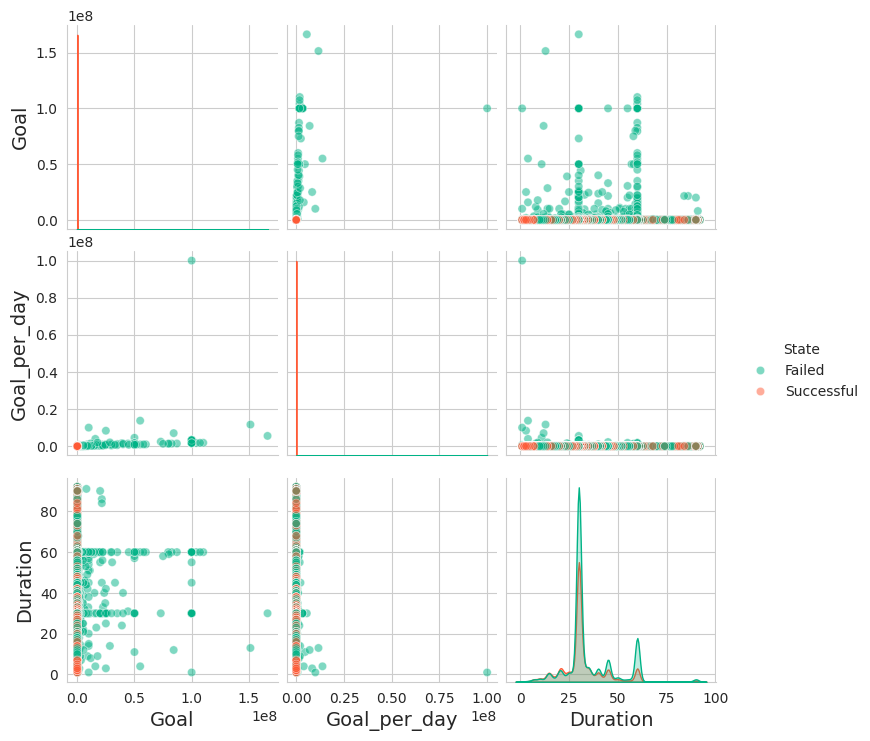

In [ ]:
sns.pairplot(df, vars=['Goal','Goal_per_day','Duration'], hue='State', palette=kickstarter_colors, plot_kws={'alpha':0.5})
plt.show()

# Encoding & Confirmation

In [ ]:
# Encode Target (State -> 1 = Successful, 0 = Failed)
df['Target'] = (df['State'] == 'Successful').astype(int)

# Encode Category (One-Hot)
category_dummies = pd.get_dummies(df['Category'], prefix='Category')
df = pd.concat([df, category_dummies], axis=1)

# Encode Subcategory
# Label encoding for Tree-based models
sub_le = LabelEncoder()
df['Subcategory_Label'] = sub_le.fit_transform(df['Subcategory'])

# One-Hot encoding for Bayesian/Logistic
subcategory_dummies = pd.get_dummies(df['Subcategory'], prefix='Subcategory')
df = pd.concat([df, subcategory_dummies], axis=1)

# Encode Country
# Binary: US vs Non-US
df['US_vs_nonUS'] = (df['Country'] == 'United States').astype(int)

# One-Hot: Region (assuming 'Region' column already exists)
region_dummies = pd.get_dummies(df['Region'], prefix='Region')
df = pd.concat([df, region_dummies], axis=1)

# Encode Season (One-Hot)
season_dummies = pd.get_dummies(df['Season'], prefix='Season')
df = pd.concat([df, season_dummies], axis=1)

In [7]:
print(df.head()[[
    'Category','Subcategory','Subcategory_Label','Country','US_vs_nonUS','Region','Season','Target'
]])

print("All columns added for encoding:")
print([col for col in df.columns if 'Category_' in col or 'Subcategory_' in col or 'Region_' in col or 'Season_' in col])
print("\nTarget unique values:", df['Target'].unique())
print("US_vs_nonUS unique values:", df['US_vs_nonUS'].unique())
print("Subcategory_Label unique values:", df['Subcategory_Label'].nunique())


       Category   Subcategory  Subcategory_Label        Country  US_vs_nonUS  \
0       Fashion       Fashion                 52  United States            1   
1  Film & Video        Shorts                129  United States            1   
2           Art  Illustration                 70  United States            1   
3    Technology      Software                131  United States            1   
4       Fashion       Fashion                 52  United States            1   

          Region  Season  Target  
0  North America  Spring       0  
1  North America  Spring       0  
2  North America  Spring       1  
3  North America  Spring       1  
4  North America  Spring       0  
All columns added for encoding:
['Category_Art', 'Category_Comics', 'Category_Crafts', 'Category_Dance', 'Category_Design', 'Category_Fashion', 'Category_Film & Video', 'Category_Food', 'Category_Games', 'Category_Journalism', 'Category_Music', 'Category_Photography', 'Category_Publishing', 'Category_Technol

In [47]:
print(df.columns.tolist())
critical_cols = ['Duration','Season','Goal_per_day','US_vs_nonUS',
                 'Region','Launch_Year','Goal_bin','Target','Subcategory_Label']
for col in critical_cols:
    print(f"{col}: {'present' if col in df.columns else 'missing'}")

df.head()

['Category', 'Subcategory', 'Country', 'Launched', 'Deadline', 'Goal', 'State', 'Duration', 'Season', 'Goal_per_day', 'US_vs_nonUS', 'Region', 'Launch_Year', 'Goal_bin', 'Target', 'Category_Art', 'Category_Comics', 'Category_Crafts', 'Category_Dance', 'Category_Design', 'Category_Fashion', 'Category_Film & Video', 'Category_Food', 'Category_Games', 'Category_Journalism', 'Category_Music', 'Category_Photography', 'Category_Publishing', 'Category_Technology', 'Category_Theater', 'Subcategory_Label', 'Subcategory_3D Printing', 'Subcategory_Academic', 'Subcategory_Accessories', 'Subcategory_Action', 'Subcategory_Animals', 'Subcategory_Animation', 'Subcategory_Anthologies', 'Subcategory_Apparel', 'Subcategory_Apps', 'Subcategory_Architecture', 'Subcategory_Art', 'Subcategory_Art Books', 'Subcategory_Audio', 'Subcategory_Bacon', 'Subcategory_Blues', 'Subcategory_Calendars', 'Subcategory_Camera Equipment', 'Subcategory_Candles', 'Subcategory_Ceramics', "Subcategory_Children's Books", 'Subcate

,Category,Subcategory,Country,Launched,Deadline,Goal,State,Duration,Season,Goal_per_day,...,Subcategory_Zines,Region_Asia,Region_Europe,Region_North America,Region_Oceania,Region_Other,Season_Autumn,Season_Spring,Season_Summer,Season_Winter
0,Fashion,Fashion,United States,2009-04-21,2009-05-31,1000,Failed,40,Spring,25.000000,...,False,False,False,True,False,False,False,True,False,False
1,Film & Video,Shorts,United States,2009-04-23,2009-07-20,80000,Failed,88,Spring,909.090909,...,False,False,False,True,False,False,False,True,False,False
2,Art,Illustration,United States,2009-04-24,2009-05-03,20,Successful,9,Spring,2.222222,...,False,False,False,True,False,False,False,True,False,False
3,Technology,Software,United States,2009-04-25,2009-07-14,99,Successful,80,Spring,1.237500,...,False,False,False,True,False,False,False,True,False,False
4,Fashion,Fashion,United States,2009-04-27,2009-05-26,1900,Failed,29,Spring,65.517241,...,False,False,False,True,False,False,False,True,False,False


In [48]:
print("Rows, Cols:", df.shape)
print(df['Target'].value_counts(normalize=True))
print(df.isnull().sum()[df.isnull().sum()>0])

Rows, Cols: (331462, 199)
Target
0    0.59618
1    0.40382
Name: proportion, dtype: float64
Series([], dtype: int64)


In [49]:
cat_ohe = [c for c in df.columns if c.startswith("Category_")]
sub_ohe = [c for c in df.columns if c.startswith("Subcategory_")]
region_ohe = [c for c in df.columns if c.startswith("Region_")]
season_ohe = [c for c in df.columns if c.startswith("Season_")]
print("Category OHE cols:", len(cat_ohe))
print("Subcategory OHE cols:", len(sub_ohe))
print("Region OHE cols:", len(region_ohe))
print("Season OHE cols:", len(season_ohe))


Category OHE cols: 15
Subcategory OHE cols: 160
Region OHE cols: 5
Season OHE cols: 4


In [50]:
if "Subcategory_Label" not in df.columns:
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    df["Subcategory_Label"] = le.fit_transform(df["Subcategory"].astype(str))

In [51]:
print(df.dtypes)
print(df.head(3))
print(df.isnull().sum())

Category                           object
Subcategory                        object
Country                            object
Launched                           object
Deadline                           object
Goal                                int64
State                              object
Duration                            int64
Season                             object
Goal_per_day                      float64
US_vs_nonUS                         int64
Region                             object
Launch_Year                         int64
Goal_bin                           object
Target                              int64
Category_Art                         bool
Category_Comics                      bool
Category_Crafts                      bool
Category_Dance                       bool
Category_Design                      bool
Category_Fashion                     bool
Category_Film & Video                bool
Category_Food                        bool
Category_Games                    

In [52]:
df["Launched"] = pd.to_datetime(df["Launched"], errors="coerce")
df["Deadline"] = pd.to_datetime(df["Deadline"], errors="coerce")
df = df.astype({col: int for col in df.select_dtypes(bool).columns})
pd.set_option("display.max_rows", None)
print(df.dtypes)

Category                                  object
Subcategory                               object
Country                                   object
Launched                          datetime64[ns]
Deadline                          datetime64[ns]
Goal                                       int64
State                                     object
Duration                                   int64
Season                                    object
Goal_per_day                             float64
US_vs_nonUS                                int64
Region                                    object
Launch_Year                                int64
Goal_bin                                  object
Target                                     int64
Category_Art                               int64
Category_Comics                            int64
Category_Crafts                            int64
Category_Dance                             int64
Category_Design                            int64
Category_Fashion    

# CSV Extraction If Needed

In [ ]:
output_path = "kickstarter_processed.csv"
df.to_csv(output_path, index=False)
files.download(output_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Bayesian Network

In [53]:
top_n = 20
sample_for_structure = 50000

required_cols = ['Subcategory', 'Goal_bin', 'Duration', 'Target']
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise KeyError(f"Missing columns required for Bayesian Network: {missing}")

top_subs = df['Subcategory'].value_counts().nlargest(top_n).index
df['Subcategory_reduced'] = df['Subcategory'].where(df['Subcategory'].isin(top_subs), other='Other')

df['Duration_bin'] = pd.qcut(df['Duration'], q=4, duplicates='drop').astype(str)

df['Goal_bin'] = df['Goal_bin'].astype(str)

bn_cols = ['Subcategory_reduced', 'Goal_bin', 'Duration_bin', 'Target']
bn_df = df[bn_cols].dropna().copy()

if len(bn_df) > sample_for_structure:
    bn_sample = bn_df.sample(n=sample_for_structure, random_state=42).reset_index(drop=True)
else:
    bn_sample = bn_df.reset_index(drop=True)

print("Sample size for structure learning:", len(bn_sample))
print("Unique values per column:")
for c in bn_sample.columns:
    print(c, bn_sample[c].nunique())

/tmp/ipython-input-2172509933.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Subcategory_reduced'] = df['Subcategory'].where(df['Subcategory'].isin(top_subs), other='Other')
/tmp/ipython-input-2172509933.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Duration_bin'] = pd.qcut(df['Duration'], q=4, duplicates='drop').astype(str)


Sample size for structure learning: 50000
Unique values per column:
Subcategory_reduced 21
Goal_bin 10
Duration_bin 3
Target 2


In [54]:
for c in ['Subcategory_reduced', 'Goal_bin', 'Duration_bin', 'Target']:
    print(c, "->", bn_sample[c].unique()[:20], " (n_states=", bn_sample[c].nunique(), ")")

Subcategory_reduced -> ['Other' 'Fiction' 'Music' 'Product Design' 'Documentary' 'Food'
 'Tabletop Games' 'Shorts' 'Indie Rock' 'Photography' 'Video Games'
 'Technology' "Children's Books" 'Fashion' 'Apps' 'Art' 'Theater'
 'Nonfiction' 'Apparel' 'Rock']  (n_states= 21 )
Goal_bin -> ['(5000.0, 8000.0]' '(3975.0, 5000.0]' '(8000.0, 11906.7]'
 '(40000.0, 166361391.0]' '(1500.0, 2500.0]' '(11906.7, 20000.0]'
 '(20000.0, 40000.0]' '(2500.0, 3975.0]' '(673.0, 1500.0]'
 '(-0.001, 673.0]']  (n_states= 10 )
Duration_bin -> ['(0.999, 30.0]' '(36.0, 92.0]' '(30.0, 36.0]']  (n_states= 3 )
Target -> [0 1]  (n_states= 2 )


In [55]:
hc = HillClimbSearch(bn_sample)
best_model = hc.estimate(scoring_method=BicScore(bn_sample))

print("Learned edges (DAG):")
print(best_model.edges())

  0%|          | 0/1000000 [00:00<?, ?it/s]

Learned edges (DAG):
[('Goal_bin', 'Subcategory_reduced'), ('Goal_bin', 'Duration_bin'), ('Target', 'Goal_bin'), ('Target', 'Duration_bin'), ('Target', 'Subcategory_reduced')]


In [56]:
top_n = 20
sample_for_structure = 50000

top_subs = df['Subcategory'].value_counts().nlargest(top_n).index
df['Subcategory_reduced'] = df['Subcategory'].where(df['Subcategory'].isin(top_subs), other='Other')

df['Duration_bin'] = pd.qcut(df['Duration'], q=4, duplicates='drop').astype(str)

df['Goal_bin'] = df['Goal_bin'].astype(str)

bn_cols = ['Subcategory_reduced', 'Goal_bin', 'Duration_bin', 'Target']
bn_df = df[bn_cols].dropna().copy()

bn_sample = bn_df.sample(n=min(sample_for_structure, len(bn_df)), random_state=42).reset_index(drop=True)

hc = HillClimbSearch(bn_sample)
best_model = hc.estimate(scoring_method=BicScore(bn_sample))
print("Learned edges (DAG):", best_model.edges())

model = BayesianNetwork(best_model.edges())
model.fit(bn_df, estimator=MaximumLikelihoodEstimator)

infer = VariableElimination(model)

for var in ['Subcategory_reduced', 'Goal_bin', 'Duration_bin']:
    print(f"{var} states: {model.get_cpds(var).state_names[var]}")

example_evidence = {
    'Subcategory_reduced': model.get_cpds('Subcategory_reduced').state_names['Subcategory_reduced'][0],
    'Goal_bin': model.get_cpds('Goal_bin').state_names['Goal_bin'][0],
    'Duration_bin': model.get_cpds('Duration_bin').state_names['Duration_bin'][0]
}
print("Example evidence:", example_evidence)

q = infer.query(variables=['Target'], evidence=example_evidence, show_progress=False)
print("\nQuery result distribution over Target:")
print(q)

prob_success = float(q.values[1])
print(f"P(Target=1 | evidence) = {prob_success:.4f}")

train_df, test_df = train_test_split(bn_df, test_size=0.2, random_state=42, stratify=bn_df['Target'])
model.fit(train_df, estimator=MaximumLikelihoodEstimator)
infer = VariableElimination(model)

eval_n = min(5000, len(test_df))
test_small = test_df.sample(n=eval_n, random_state=42).reset_index(drop=True)

def predict_prob_success(row):
    evidence = {
        'Subcategory_reduced': row['Subcategory_reduced'],
        'Goal_bin': row['Goal_bin'],
        'Duration_bin': row['Duration_bin']
    }
    q = infer.query(variables=['Target'], evidence=evidence, show_progress=False)
    return float(q.values[1])

test_small['pred_prob'] = test_small.apply(predict_prob_success, axis=1)
test_small['pred'] = (test_small['pred_prob'] >= 0.5).astype(int)

y_true = test_small['Target']
y_pred = test_small['pred']

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, zero_division=0))
print("Recall:", recall_score(y_true, y_pred, zero_division=0))
print("F1:", f1_score(y_true, y_pred, zero_division=0))
try:
    print("ROC-AUC:", roc_auc_score(y_true, test_small['pred_prob']))
except Exception as e:
    print("ROC-AUC could not be computed:", e)


  0%|          | 0/1000000 [00:00<?, ?it/s]

Learned edges (DAG): [('Goal_bin', 'Subcategory_reduced'), ('Goal_bin', 'Duration_bin'), ('Target', 'Goal_bin'), ('Target', 'Duration_bin'), ('Target', 'Subcategory_reduced')]
Subcategory_reduced states: ['Apparel', 'Apps', 'Art', "Children's Books", 'Documentary', 'Fashion', 'Fiction', 'Film & Video', 'Food', 'Indie Rock', 'Music', 'Nonfiction', 'Other', 'Photography', 'Product Design', 'Rock', 'Shorts', 'Tabletop Games', 'Technology', 'Theater', 'Video Games']
Goal_bin states: ['(-0.001, 673.0]', '(11906.7, 20000.0]', '(1500.0, 2500.0]', '(20000.0, 40000.0]', '(2500.0, 3975.0]', '(3975.0, 5000.0]', '(40000.0, 166361391.0]', '(5000.0, 8000.0]', '(673.0, 1500.0]', '(8000.0, 11906.7]']
Duration_bin states: ['(0.999, 30.0]', '(30.0, 36.0]', '(36.0, 92.0]']
Example evidence: {'Subcategory_reduced': 'Apparel', 'Goal_bin': '(-0.001, 673.0]', 'Duration_bin': '(0.999, 30.0]'}

Query result distribution over Target:
+-----------+---------------+
| Target    |   phi(Target) |
+===========+=====

In [57]:
top_subcats = bn_df['Subcategory_reduced'].value_counts().nlargest(10).index
goal_bins = model.get_cpds('Goal_bin').state_names['Goal_bin']
duration_bins = model.get_cpds('Duration_bin').state_names['Duration_bin']

results = []

for s in top_subcats:
    for g in goal_bins:
        for d in duration_bins:
            try:
                q = infer.query(
                    variables=['Target'],
                    evidence={'Subcategory_reduced': s, 'Goal_bin': g, 'Duration_bin': d},
                    show_progress=False
                )
                prob_success = float(q.values[1])
                results.append((s, g, d, prob_success))
            except Exception:
                continue

res_df = pd.DataFrame(results, columns=['Subcategory', 'Goal_bin', 'Duration_bin', 'P_success'])
print(res_df.sort_values('P_success', ascending=False).head(20))

        Subcategory           Goal_bin   Duration_bin  P_success
121  Tabletop Games    (-0.001, 673.0]   (30.0, 36.0]   0.906695
145  Tabletop Games    (673.0, 1500.0]   (30.0, 36.0]   0.869912
120  Tabletop Games    (-0.001, 673.0]  (0.999, 30.0]   0.868345
127  Tabletop Games   (1500.0, 2500.0]   (30.0, 36.0]   0.844402
122  Tabletop Games    (-0.001, 673.0]   (36.0, 92.0]   0.841510
136  Tabletop Games   (3975.0, 5000.0]   (30.0, 36.0]   0.824309
133  Tabletop Games   (2500.0, 3975.0]   (30.0, 36.0]   0.813258
144  Tabletop Games    (673.0, 1500.0]  (0.999, 30.0]   0.808685
146  Tabletop Games    (673.0, 1500.0]   (36.0, 92.0]   0.772390
142  Tabletop Games   (5000.0, 8000.0]   (30.0, 36.0]   0.770399
31   Product Design    (-0.001, 673.0]   (30.0, 36.0]   0.760431
126  Tabletop Games   (1500.0, 2500.0]  (0.999, 30.0]   0.760119
151          Shorts    (-0.001, 673.0]   (30.0, 36.0]   0.758639
148  Tabletop Games  (8000.0, 11906.7]   (30.0, 36.0]   0.755354
157          Shorts   (15

In [58]:
df['Duration'] = (df['Deadline'] - df['Launched']).dt.days
df['Duration_bin'] = pd.qcut(df['Duration'], q=4, duplicates='drop').astype(str)
df['Goal_bin'] = pd.qcut(df['Goal'], q=10, duplicates='drop').astype(str)
subcats = df['Subcategory'].unique()
df['Subcategory_reduced'] = df['Subcategory'].where(df['Subcategory'].isin(subcats), 'Other')
df['Region'] = df['Region'].astype(str)
df['Category'] = df['Category'].astype(str)
bn_cols = ['Category', 'Subcategory_reduced', 'Goal_bin', 'Duration_bin', 'Region', 'Target']
bn_df = df[bn_cols].dropna().copy()
sample_for_structure = 50000
if len(bn_df) > sample_for_structure:
    bn_sample = bn_df.sample(n=sample_for_structure, random_state=42).reset_index(drop=True)
else:
    bn_sample = bn_df.reset_index(drop=True)

hc = HillClimbSearch(bn_sample)
best_model = hc.estimate(scoring_method=BicScore(bn_sample))

print("Learned edges (DAG):")
print(best_model.edges())
model = BayesianModel(best_model.edges())
model.fit(bn_df, estimator=MaximumLikelihoodEstimator)

infer = VariableElimination(model)

example_evidence = {
    'Category': 'Games',
    'Subcategory_reduced': 'Tabletop Games',
    'Goal_bin': '(673.0, 1500.0]',
    'Duration_bin': '(36.0, 92.0]',
    'Region': 'North America'
}
q = infer.query(variables=['Target'], evidence=example_evidence, show_progress=False)
print("P(Target=1 | evidence):", float(q.values[1]))

train_df, test_df = train_test_split(bn_df, test_size=0.2, random_state=42, stratify=bn_df['Target'])

model = BayesianModel(best_model.edges())
model.fit(train_df, estimator=MaximumLikelihoodEstimator)
infer = VariableElimination(model)

eval_n = min(5000, len(test_df))
test_small = test_df.sample(n=eval_n, random_state=42).reset_index(drop=True)

def predict_prob_success(row):
    evidence = {
        'Category': row['Category'],
        'Subcategory_reduced': row['Subcategory_reduced'],
        'Goal_bin': row['Goal_bin'],
        'Duration_bin': row['Duration_bin'],
        'Region': row['Region']
    }
    q = infer.query(variables=['Target'], evidence=evidence, show_progress=False)
    return float(q.values[1])

test_small['pred_prob'] = test_small.apply(predict_prob_success, axis=1)
test_small['pred'] = (test_small['pred_prob'] >= 0.5).astype(int)

y_true = test_small['Target']
y_pred = test_small['pred']

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, zero_division=0))
print("Recall:", recall_score(y_true, y_pred, zero_division=0))
print("F1:", f1_score(y_true, y_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_true, test_small['pred_prob']))


  0%|          | 0/1000000 [00:00<?, ?it/s]

Learned edges (DAG):
[('Category', 'Goal_bin'), ('Category', 'Region'), ('Subcategory_reduced', 'Category'), ('Subcategory_reduced', 'Target'), ('Goal_bin', 'Duration_bin'), ('Target', 'Goal_bin'), ('Target', 'Duration_bin')]


/usr/local/lib/python3.12/dist-packages/pgmpy/models/BayesianModel.py:8: FutureWarning: BayesianModel has been renamed to BayesianNetwork. Please use BayesianNetwork class, BayesianModel will be removed in future.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pgmpy/models/BayesianModel.py:8: FutureWarning: BayesianModel has been renamed to BayesianNetwork. Please use BayesianNetwork class, BayesianModel will be removed in future.
  warnings.warn(


P(Target=1 | evidence): 0.7378572382389309


/usr/local/lib/python3.12/dist-packages/pgmpy/models/BayesianModel.py:8: FutureWarning: BayesianModel has been renamed to BayesianNetwork. Please use BayesianNetwork class, BayesianModel will be removed in future.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pgmpy/models/BayesianModel.py:8: FutureWarning: BayesianModel has been renamed to BayesianNetwork. Please use BayesianNetwork class, BayesianModel will be removed in future.
  warnings.warn(


Accuracy: 0.6808
Precision: 0.6233292831105711
Recall: 0.5124875124875125
F1: 0.5625
ROC-AUC: 0.7313732798222458


In [59]:
required_cols = ['Category', 'Subcategory', 'Region', 'Goal_bin', 'Duration', 'Target']
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise KeyError(f"Missing columns required for Bayesian Network: {missing}")

df['Duration_bin'] = pd.qcut(df['Duration'], q=4, duplicates='drop').astype(str)
df['Goal_bin'] = df['Goal_bin'].astype(str)
df['Subcategory_reduced'] = df['Subcategory']
bn_cols = ['Category', 'Subcategory_reduced', 'Region', 'Goal_bin', 'Duration_bin', 'Target']
bn_df = df[bn_cols].dropna().copy()

sample_for_structure = 50000
if len(bn_df) > sample_for_structure:
    bn_sample = bn_df.sample(n=sample_for_structure, random_state=42).reset_index(drop=True)
else:
    bn_sample = bn_df.reset_index(drop=True)

hc = HillClimbSearch(bn_sample)
best_model = hc.estimate(scoring_method=BicScore(bn_sample))

print("Learned edges (DAG):")
print(best_model.edges())

model = BayesianNetwork(best_model.edges())
model.fit(bn_df, estimator=BayesianEstimator, prior_type='BDeu', equivalent_sample_size=10)

for cpd in model.get_cpds():
    if cpd.variable in ['Target', 'Subcategory_reduced', 'Goal_bin', 'Duration_bin']:
        print(f"\nCPD for {cpd.variable}:")
        print(cpd)

infer = VariableElimination(model)

example_evidence = {
    'Category': 'Games',
    'Subcategory_reduced': 'Tabletop Games',
    'Region': 'North America',
    'Goal_bin': '(673.0, 1500.0]',
    'Duration_bin': '(36.0, 92.0]'
}

q = infer.query(variables=['Target'], evidence=example_evidence, show_progress=False)
print("\nExample evidence:", example_evidence)
print("\nQuery result distribution over Target:")
print(q)

prob_success = float(q.values[1])
print(f"P(Target=1 | evidence) = {prob_success:.4f}")

train_df, test_df = train_test_split(bn_df, test_size=0.2, random_state=42, stratify=bn_df['Target'])

model = BayesianNetwork(best_model.edges())
model.fit(train_df, estimator=BayesianEstimator, prior_type='BDeu', equivalent_sample_size=10)
infer = VariableElimination(model)

eval_n = min(5000, len(test_df))
test_small = test_df.sample(n=eval_n, random_state=42).reset_index(drop=True)

def predict_prob_success(row):
    evidence = {
        'Category': row['Category'],
        'Subcategory_reduced': row['Subcategory_reduced'],
        'Region': row['Region'],
        'Goal_bin': row['Goal_bin'],
        'Duration_bin': row['Duration_bin']
    }
    q = infer.query(variables=['Target'], evidence=evidence, show_progress=False)
    return float(q.values[1])

test_small['pred_prob'] = test_small.apply(predict_prob_success, axis=1)
test_small['pred'] = (test_small['pred_prob'] >= 0.5).astype(int)

y_true = test_small['Target']
y_pred = test_small['pred']

print("\nEvaluation metrics:")
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, zero_division=0))
print("Recall:", recall_score(y_true, y_pred, zero_division=0))
print("F1:", f1_score(y_true, y_pred, zero_division=0))
try:
    print("ROC-AUC:", roc_auc_score(y_true, test_small['pred_prob']))
except Exception as e:
    print("ROC-AUC could not be computed:", e)


  0%|          | 0/1000000 [00:00<?, ?it/s]

Learned edges (DAG):
[('Category', 'Goal_bin'), ('Category', 'Region'), ('Subcategory_reduced', 'Category'), ('Subcategory_reduced', 'Target'), ('Goal_bin', 'Duration_bin'), ('Target', 'Goal_bin'), ('Target', 'Duration_bin')]

CPD for Goal_bin:
+----------------------------------+-----+----------------------+
| Category                         | ... | Category(Theater)    |
+----------------------------------+-----+----------------------+
| Target                           | ... | Target(1)            |
+----------------------------------+-----+----------------------+
| Goal_bin((-0.001, 673.0])        | ... | 0.12136407692700096  |
+----------------------------------+-----+----------------------+
| Goal_bin((11906.7, 20000.0])     | ... | 0.04821200836606643  |
+----------------------------------+-----+----------------------+
| Goal_bin((1500.0, 2500.0])       | ... | 0.17691679844921696  |
+----------------------------------+-----+----------------------+
| Goal_bin((20000.0, 40000.0]

In [60]:
required_cols = ['Category', 'Subcategory', 'Region', 'Goal', 'Duration', 'Target']
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise KeyError(f"Missing columns required for Bayesian Network: {missing}")

df['Goal_bin'] = pd.qcut(df['Goal'], q=10, duplicates='drop').astype(str)
df['Duration_bin'] = pd.qcut(df['Duration'], q=4, duplicates='drop').astype(str)
df['Goal_per_day'] = df['Goal'] / df['Duration']
df['Goal_per_day_bin'] = pd.qcut(df['Goal_per_day'], q=5, duplicates='drop').astype(str)
df['Launch_month'] = df['Launched'].dt.month
df['Launch_month_bin'] = pd.cut(df['Launch_month'], bins=[0,3,6,9,12], labels=['Q1','Q2','Q3','Q4']).astype(str)
df['Subcategory_reduced'] = df['Subcategory']

bn_cols = ['Category', 'Subcategory_reduced', 'Region', 'Goal_bin', 'Duration_bin',
           'Goal_per_day_bin', 'Launch_month_bin', 'Target']
bn_df = df[bn_cols].dropna().copy()

sample_for_structure = 50000
if len(bn_df) > sample_for_structure:
    bn_sample = bn_df.sample(n=sample_for_structure, random_state=42).reset_index(drop=True)
else:
    bn_sample = bn_df.reset_index(drop=True)

hc = HillClimbSearch(bn_sample)
best_model = hc.estimate(scoring_method=BicScore(bn_sample))
print("Learned edges (DAG):", best_model.edges())

model = BayesianNetwork(best_model.edges())
model.fit(bn_df, estimator=BayesianEstimator, prior_type='BDeu', equivalent_sample_size=10)

for cpd in model.get_cpds():
    if cpd.variable in ['Target', 'Subcategory_reduced', 'Goal_bin', 'Duration_bin']:
        print(f"\nCPD for {cpd.variable}:\n", cpd)

infer = VariableElimination(model)

def map_to_bin(value, column_name):
    """Given a numeric value and a column, return the bin label from bn_df"""
    bins = bn_df[column_name].unique()
    for b in bins:
        try:
            if pd.Interval(left=float(b.split(',')[0][1:]), right=float(b.split(',')[1][:-1])).contains(value):
                return b
        except Exception:
            if str(value) == b:
                return b
    return bins[0]

example_evidence = {
    'Category': 'Games',
    'Subcategory_reduced': 'Tabletop Games',
    'Region': 'North America',
    'Goal_bin': map_to_bin(1000, 'Goal_bin'),
    'Duration_bin': map_to_bin(50, 'Duration_bin'),
    'Goal_per_day_bin': map_to_bin(20, 'Goal_per_day_bin'),
    'Launch_month_bin': 'Q2'
}

q = infer.query(variables=['Target'], evidence=example_evidence, show_progress=False)
print("\nExample evidence:", example_evidence)
print("\nQuery result distribution over Target:\n", q)
print(f"P(Target=1 | evidence) = {float(q.values[1]):.4f}")

train_df, test_df = train_test_split(bn_df, test_size=0.2, random_state=42, stratify=bn_df['Target'])
model = BayesianNetwork(best_model.edges())
model.fit(train_df, estimator=BayesianEstimator, prior_type='BDeu', equivalent_sample_size=10)
infer = VariableElimination(model)

eval_n = min(5000, len(test_df))
test_small = test_df.sample(n=eval_n, random_state=42).reset_index(drop=True)

def predict_prob_success(row):
    evidence = {
        'Category': row['Category'],
        'Subcategory_reduced': row['Subcategory_reduced'],
        'Region': row['Region'],
        'Goal_bin': row['Goal_bin'],
        'Duration_bin': row['Duration_bin'],
        'Goal_per_day_bin': row['Goal_per_day_bin'],
        'Launch_month_bin': row['Launch_month_bin']
    }
    q = infer.query(variables=['Target'], evidence=evidence, show_progress=False)
    return float(q.values[1])

test_small['pred_prob'] = test_small.apply(predict_prob_success, axis=1)
test_small['pred'] = (test_small['pred_prob'] >= 0.5).astype(int)

y_true = test_small['Target']
y_pred = test_small['pred']

print("\nEvaluation metrics:")
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, zero_division=0))
print("Recall:", recall_score(y_true, y_pred, zero_division=0))
print("F1:", f1_score(y_true, y_pred, zero_division=0))
try:
    print("ROC-AUC:", roc_auc_score(y_true, test_small['pred_prob']))
except Exception as e:
    print("ROC-AUC could not be computed:", e)


/tmp/ipython-input-840507341.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Goal_per_day_bin'] = pd.qcut(df['Goal_per_day'], q=5, duplicates='drop').astype(str)
/tmp/ipython-input-840507341.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Launch_month'] = df['Launched'].dt.month
/tmp/ipython-input-840507341.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(a

  0%|          | 0/1000000 [00:00<?, ?it/s]

Learned edges (DAG): [('Category', 'Subcategory_reduced'), ('Category', 'Goal_bin'), ('Category', 'Region'), ('Subcategory_reduced', 'Target'), ('Goal_bin', 'Goal_per_day_bin'), ('Goal_bin', 'Duration_bin'), ('Duration_bin', 'Goal_per_day_bin'), ('Target', 'Goal_bin'), ('Target', 'Duration_bin'), ('Target', 'Launch_month_bin')]

CPD for Subcategory_reduced:
 +-----+-----------------------+
| ... | Category(Theater)     |
+-----+-----------------------+
| ... | 4.093535652239413e-07 |
+-----+-----------------------+
| ... | 4.093535652239413e-07 |
+-----+-----------------------+
| ... | 4.093535652239413e-07 |
+-----+-----------------------+
| ... | 4.093535652239413e-07 |
+-----+-----------------------+
| ... | 4.093535652239413e-07 |
+-----+-----------------------+
| ... | 4.093535652239413e-07 |
+-----+-----------------------+
| ... | 4.093535652239413e-07 |
+-----+-----------------------+
| ... | 4.093535652239413e-07 |
+-----+-----------------------+
| ... | 4.093535652239413e-07 |

In [61]:
infer = VariableElimination(model)

def predict_success(evidence: dict) -> float:
    """
    Predict probability of success (Target=1) given project evidence.

    Parameters:
        evidence (dict): Dictionary of feature values, e.g.
            {
                'Category': 'Games',
                'Subcategory_reduced': 'Tabletop Games',
                'Region': 'North America',
                'Goal_bin': '(673.0, 1500.0]',
                'Duration_bin': '(36.0, 92.0]',
                'Goal_per_day_bin': '(-0.001, 48.387]',
                'Launch_month_bin': 'Q2'
            }
    Returns:
        float: Probability of success (Target=1)
    """
    try:
        result = infer.query(variables=['Target'], evidence=evidence, show_progress=False)
        prob_success = result.values[1]  # Index 1 corresponds to Target=1
        return prob_success
    except KeyError as e:
        print(f"Error: Evidence contains unknown state or feature: {e}")
        return None

example_evidence = {
    'Category': 'Games',
    'Subcategory_reduced': 'Tabletop Games',
    'Region': 'North America',
    'Goal_bin': '(673.0, 1500.0]',
    'Duration_bin': '(36.0, 92.0]',
    'Goal_per_day_bin': '(-0.001, 48.387]',
    'Launch_month_bin': 'Q2'
}

prob = predict_success(example_evidence)
print(f"P(Target=1 | evidence) = {prob:.4f}")


P(Target=1 | evidence) = 0.7527


In [62]:
class BNBinnedPredictor:
    def __init__(self, model, bn_df):
        """
        Initialize the BN predictor.

        Parameters:
            model: Trained BayesianNetwork (with CPDs fitted)
            bn_df: DataFrame used for BN, including binned columns
        """
        self.model = model
        self.infer = VariableElimination(model)
        self.bn_df = bn_df

    def map_to_bin(self, value, column_name):
        """Map numeric value to a bin label used in bn_df."""
        bins = self.bn_df[column_name].unique()
        for b in bins:
            try:
                if pd.Interval(left=float(b.split(',')[0][1:]),
                               right=float(b.split(',')[1][:-1])).contains(value):
                    return b
            except Exception:
                if str(value) == b:
                    return b
        return bins[0]

    def prepare_evidence(self, evidence):
        """
        Convert numeric features to binned versions if needed.
        Expected numeric keys: 'Goal', 'Duration', 'Goal_per_day'
        """
        evidence_binned = evidence.copy()

        if 'Goal' in evidence:
            evidence_binned['Goal_bin'] = self.map_to_bin(evidence['Goal'], 'Goal_bin')
            del evidence_binned['Goal']

        if 'Duration' in evidence:
            evidence_binned['Duration_bin'] = self.map_to_bin(evidence['Duration'], 'Duration_bin')
            del evidence_binned['Duration']

        if 'Goal_per_day' in evidence:
            evidence_binned['Goal_per_day_bin'] = self.map_to_bin(evidence['Goal_per_day'], 'Goal_per_day_bin')
            del evidence_binned['Goal_per_day']

        if 'Goal' in evidence and 'Duration' in evidence:
            gpd = evidence['Goal'] / evidence['Duration']
            evidence_binned['Goal_per_day_bin'] = self.map_to_bin(gpd, 'Goal_per_day_bin')

        return evidence_binned

    def predict_success(self, evidence):
        """
        Predict probability of Target=1 given evidence.
        Automatically maps numeric features to bins.
        """
        evidence_binned = self.prepare_evidence(evidence)
        try:
            result = self.infer.query(variables=['Target'], evidence=evidence_binned, show_progress=False)
            prob_success = float(result.values[1])
            return prob_success
        except KeyError as e:
            print(f"Error: Evidence contains unknown state or feature: {e}")
            return None


In [63]:
bn_predictor = BNBinnedPredictor(model, bn_df)

example_evidence = {
    'Category': 'Games',
    'Subcategory_reduced': 'Tabletop Games',
    'Region': 'North America',
    'Goal': 1000,
    'Duration': 50,
    'Launch_month_bin': 'Q2'
}

prob = bn_predictor.predict_success(example_evidence)
print(f"P(Target=1 | evidence) = {prob:.4f}")


P(Target=1 | evidence) = 0.7527


In [64]:
bn_df_full = df[[
    'Category', 'Subcategory_reduced', 'Region',
    'Goal', 'Duration', 'Goal_per_day',
    'Goal_bin', 'Duration_bin', 'Goal_per_day_bin',
    'Launch_month_bin', 'Target'
]].dropna().copy()

train_df, test_df = train_test_split(
    bn_df_full, test_size=0.2, random_state=42, stratify=bn_df_full['Target']
)

model = BayesianNetwork(best_model.edges())
model.fit(train_df, estimator=BayesianEstimator, prior_type='BDeu', equivalent_sample_size=10)

predictor = BNBinnedPredictor(model=model, bn_df=train_df)

eval_n = min(100, len(test_df))
test_small = test_df.sample(n=eval_n, random_state=42).reset_index(drop=True)

def predict_prob_success_row(row):
    evidence = {
        'Category': row['Category'],
        'Subcategory_reduced': row['Subcategory_reduced'],
        'Region': row['Region'],
        'Goal': row['Goal'],
        'Duration': row['Duration'],
        'Launch_month_bin': row['Launch_month_bin']
    }
    return predictor.predict_success(evidence)

test_small['pred_prob'] = test_small.apply(predict_prob_success_row, axis=1)
test_small['pred'] = (test_small['pred_prob'] >= 0.5).astype(int)

y_true = test_small['Target']
y_pred = test_small['pred']

print("\nEvaluation metrics:")
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, zero_division=0))
print("Recall:", recall_score(y_true, y_pred, zero_division=0))
print("F1:", f1_score(y_true, y_pred, zero_division=0))
try:
    print("ROC-AUC:", roc_auc_score(y_true, test_small['pred_prob']))
except Exception as e:
    print("ROC-AUC could not be computed:", e)



Evaluation metrics:
Accuracy: 0.71
Precision: 0.6551724137931034
Recall: 0.8085106382978723
F1: 0.7238095238095238
ROC-AUC: 0.7346447209955841


In [65]:
required_cols = ['Category', 'Subcategory', 'Region', 'Goal', 'Duration', 'Target', 'Launched']
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise KeyError(f"Missing columns required for Bayesian Network: {missing}")

df['Goal_bin'] = pd.qcut(df['Goal'], q=10, duplicates='drop').astype(str)
df['Duration_bin'] = pd.qcut(df['Duration'], q=4, duplicates='drop').astype(str)
df['Goal_per_day'] = df['Goal'] / df['Duration']
df['Goal_per_day_bin'] = pd.qcut(df['Goal_per_day'], q=5, duplicates='drop').astype(str)
df['Launch_month'] = df['Launched'].dt.month
df['Launch_month_bin'] = pd.cut(df['Launch_month'], bins=[0,3,6,9,12], labels=['Q1','Q2','Q3','Q4']).astype(str)
df['Subcategory_reduced'] = df['Subcategory']
bn_cols = ['Category', 'Subcategory_reduced', 'Region', 'Goal_bin', 'Duration_bin',
           'Goal_per_day_bin', 'Launch_month_bin', 'Target']
bn_df = df[bn_cols].dropna().copy()

sample_for_structure = 50000
if len(bn_df) > sample_for_structure:
    bn_sample = bn_df.sample(n=sample_for_structure, random_state=42).reset_index(drop=True)
else:
    bn_sample = bn_df.reset_index(drop=True)

hc = HillClimbSearch(bn_sample)
best_model = hc.estimate(scoring_method=BicScore(bn_sample))
print("Learned edges (DAG):", best_model.edges())

model = BayesianNetwork(best_model.edges())
model.fit(bn_df, estimator=BayesianEstimator, prior_type='BDeu', equivalent_sample_size=10)

for cpd in model.get_cpds():
    if cpd.variable in ['Target', 'Subcategory_reduced', 'Goal_bin', 'Duration_bin']:
        print(f"\nCPD for {cpd.variable}:\n", cpd)

infer = VariableElimination(model)

class BNBinnedPredictor:
    def __init__(self, model, bn_df):
        self.model = model
        self.infer = VariableElimination(model)
        self.bn_df = bn_df

    def map_to_bin(self, value, column_name):
        bins = self.bn_df[column_name].unique()
        for b in bins:
            try:
                if pd.Interval(left=float(b.split(',')[0][1:]),
                               right=float(b.split(',')[1][:-1])).contains(value):
                    return b
            except Exception:
                if str(value) == b:
                    return b
        return bins[0]

    def prepare_evidence(self, evidence):
        evidence_binned = evidence.copy()

        if 'Goal' in evidence:
            evidence_binned['Goal_bin'] = self.map_to_bin(evidence['Goal'], 'Goal_bin')
            del evidence_binned['Goal']

        if 'Duration' in evidence:
            evidence_binned['Duration_bin'] = self.map_to_bin(evidence['Duration'], 'Duration_bin')
            del evidence_binned['Duration']

        if 'Goal_per_day' in evidence:
            evidence_binned['Goal_per_day_bin'] = self.map_to_bin(evidence['Goal_per_day'], 'Goal_per_day_bin')
            del evidence_binned['Goal_per_day']

        if 'Goal_bin' in evidence_binned and 'Duration_bin' in evidence_binned and 'Goal_per_day_bin' not in evidence_binned:
            gpd = evidence.get('Goal', 1) / evidence.get('Duration', 1)
            evidence_binned['Goal_per_day_bin'] = self.map_to_bin(gpd, 'Goal_per_day_bin')

        return evidence_binned

    def predict_success(self, evidence):
        evidence_binned = self.prepare_evidence(evidence)
        try:
            result = self.infer.query(variables=['Target'], evidence=evidence_binned, show_progress=False)
            prob_success = float(result.values[1])
            return prob_success
        except KeyError as e:
            print(f"Error: Evidence contains unknown state or feature: {e}")
            return None

predictor = BNBinnedPredictor(model, bn_df)
example_evidence = {
    'Category': 'Games',
    'Subcategory_reduced': 'Tabletop Games',
    'Region': 'North America',
    'Goal': 1000,
    'Duration': 50,
    'Goal_per_day': 20,
    'Launch_month_bin': 'Q2'
}

prob = predictor.predict_success(example_evidence)
print(f"Probability of success (Target=1): {prob:.4f}")

train_df, test_df = train_test_split(bn_df, test_size=0.2, random_state=42, stratify=bn_df['Target'])
model.fit(train_df, estimator=BayesianEstimator, prior_type='BDeu', equivalent_sample_size=10)
predictor = BNBinnedPredictor(model, bn_df)

eval_n = min(5000, len(test_df))
test_small = test_df.sample(n=eval_n, random_state=42).reset_index(drop=True)

def predict_prob_success(row):
    evidence = {
        'Category': row['Category'],
        'Subcategory_reduced': row['Subcategory_reduced'],
        'Region': row['Region'],
        'Goal_bin': row['Goal_bin'],
        'Duration_bin': row['Duration_bin'],
        'Goal_per_day_bin': row['Goal_per_day_bin'],
        'Launch_month_bin': row['Launch_month_bin']
    }
    return predictor.predict_success(evidence)

test_small['pred_prob'] = test_small.apply(predict_prob_success, axis=1)
test_small['pred'] = (test_small['pred_prob'] >= 0.5).astype(int)

y_true = test_small['Target']
y_pred = test_small['pred']

print("\nEvaluation metrics:")
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, zero_division=0))
print("Recall:", recall_score(y_true, y_pred, zero_division=0))
print("F1:", f1_score(y_true, y_pred, zero_division=0))
try:
    print("ROC-AUC:", roc_auc_score(y_true, test_small['pred_prob']))
except Exception as e:
    print("ROC-AUC could not be computed:", e)


  0%|          | 0/1000000 [00:00<?, ?it/s]

Learned edges (DAG): [('Category', 'Subcategory_reduced'), ('Category', 'Goal_bin'), ('Category', 'Region'), ('Subcategory_reduced', 'Target'), ('Goal_bin', 'Goal_per_day_bin'), ('Goal_bin', 'Duration_bin'), ('Duration_bin', 'Goal_per_day_bin'), ('Target', 'Goal_bin'), ('Target', 'Duration_bin'), ('Target', 'Launch_month_bin')]

CPD for Subcategory_reduced:
 +-----+-----------------------+
| ... | Category(Theater)     |
+-----+-----------------------+
| ... | 4.093535652239413e-07 |
+-----+-----------------------+
| ... | 4.093535652239413e-07 |
+-----+-----------------------+
| ... | 4.093535652239413e-07 |
+-----+-----------------------+
| ... | 4.093535652239413e-07 |
+-----+-----------------------+
| ... | 4.093535652239413e-07 |
+-----+-----------------------+
| ... | 4.093535652239413e-07 |
+-----+-----------------------+
| ... | 4.093535652239413e-07 |
+-----+-----------------------+
| ... | 4.093535652239413e-07 |
+-----+-----------------------+
| ... | 4.093535652239413e-07 |

In [66]:
class BNBinnedPredictorFast:
    def __init__(self, model, bn_df):
        self.model = model
        self.infer = VariableElimination(model)
        self.bn_df = bn_df

    def map_to_bin(self, value, column_name):
        bins = self.bn_df[column_name].unique()
        for b in bins:
            try:
                if pd.Interval(left=float(b.split(',')[0][1:]),
                               right=float(b.split(',')[1][:-1])).contains(value):
                    return b
            except Exception:
                if str(value) == b:
                    return b
        return bins[0]

    def prepare_evidence(self, df):
        """
        Convert numeric columns in a DataFrame to binned columns.
        Returns a DataFrame ready for BN inference.
        """
        df_binned = df.copy()

        for col, bin_col in [('Goal', 'Goal_bin'),
                             ('Duration', 'Duration_bin'),
                             ('Goal_per_day', 'Goal_per_day_bin')]:
            if col in df_binned.columns:
                df_binned[bin_col] = df_binned[col].apply(lambda x: self.map_to_bin(x, bin_col))
                df_binned.drop(columns=[col], inplace=True)

        if 'Goal_per_day' not in df_binned.columns and all(c in df.columns for c in ['Goal', 'Duration']):
            df_binned['Goal_per_day_bin'] = (df['Goal'] / df['Duration']).apply(
                lambda x: self.map_to_bin(x, 'Goal_per_day_bin')
            )

        return df_binned

    def predict_proba_vectorized(self, df):
        """
        Predict probability of success for all rows in df.
        Returns a Series of probabilities.
        """
        df_binned = self.prepare_evidence(df)

        probs = []
        for _, row in tqdm(df_binned.iterrows(), total=len(df_binned), desc="Predicting"):
            evidence = row.to_dict()
            evidence.pop('Target', None)
            try:
                q = self.infer.query(variables=['Target'], evidence=evidence, show_progress=False)
                probs.append(float(q.values[1]))
            except KeyError:
                probs.append(None)
        return pd.Series(probs, index=df.index)


In [67]:
predictor_fast = BNBinnedPredictorFast(model, bn_df)
test_sample = test_df.copy()
test_sample['pred_prob'] = predictor_fast.predict_proba_vectorized(test_sample)
test_sample['pred'] = (test_sample['pred_prob'] >= 0.5).astype(int)
y_true = test_sample['Target']
y_pred = test_sample['pred']

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, zero_division=0))
print("Recall:", recall_score(y_true, y_pred, zero_division=0))
print("F1:", f1_score(y_true, y_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_true, test_sample['pred_prob']))


Predicting: 100%|██████████| 66293/66293 [00:54<00:00, 1226.30it/s]

Accuracy: 0.6711719186037741
Precision: 0.6171135089289921
Recall: 0.48924168845722826
F1: 0.5457879274060801
ROC-AUC: 0.7200202492232006


In [68]:
train_ratios = [0.5, 0.6, 0.7, 0.8, 0.9]
results_df = pd.DataFrame(columns=['Train_Ratio', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC'])
for train_ratio in train_ratios:
    print(f"\nEvaluating train-test split: {int(train_ratio*100)}%-{100-int(train_ratio*100)}%")
    train_df_iter, test_df_iter = train_test_split(
        train_df, train_size=train_ratio, random_state=42, stratify=train_df['Target']
    )
    model.fit(train_df_iter, estimator=BayesianEstimator, prior_type='BDeu', equivalent_sample_size=10)
    predictor_iter = BNBinnedPredictorFast(model, bn_df)
    test_df_iter['pred_prob'] = predictor_iter.predict_proba_vectorized(test_df_iter)
    test_df_iter['pred'] = (test_df_iter['pred_prob'] >= 0.5).astype(int)

    y_true = test_df_iter['Target']
    y_pred = test_df_iter['pred']

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc = roc_auc_score(y_true, test_df_iter['pred_prob'])

    results_df = pd.concat([results_df, pd.DataFrame({
        'Train_Ratio': [train_ratio],
        'Accuracy': [acc],
        'Precision': [prec],
        'Recall': [rec],
        'F1': [f1],
        'ROC_AUC': [roc]
    })], ignore_index=True)

print("\nEvaluation results for different train-test splits:")
print(results_df)



Evaluating train-test split: 50%-50%


Predicting: 100%|██████████| 132585/132585 [01:48<00:00, 1225.31it/s]
/tmp/ipython-input-3896928024.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, pd.DataFrame({



Evaluating train-test split: 60%-40%


Predicting: 100%|██████████| 106068/106068 [01:28<00:00, 1197.77it/s]



Evaluating train-test split: 70%-30%


...


Evaluating train-test split: 80%-20%


Predicting: 100%|██████████| 53034/53034 [00:43<00:00, 1225.76it/s]



Evaluating train-test split: 90%-10%


Predicting: 100%|██████████| 26517/26517 [00:20<00:00, 1264.93it/s]



Evaluation results for different train-test splits:
   Train_Ratio  Accuracy  Precision    Recall        F1   ROC_AUC
0          0.5  0.673078   0.620315  0.490914  0.548080  0.720940
1          0.6  0.673643   0.622251  0.488222  0.547148  0.721621
2          0.7  0.673983   0.621883  0.491502  0.549058  0.722404
3          0.8  0.676623   0.626557  0.493089  0.551868  0.723877
4          0.9  0.676283   0.626791  0.490288  0.550199  0.724011


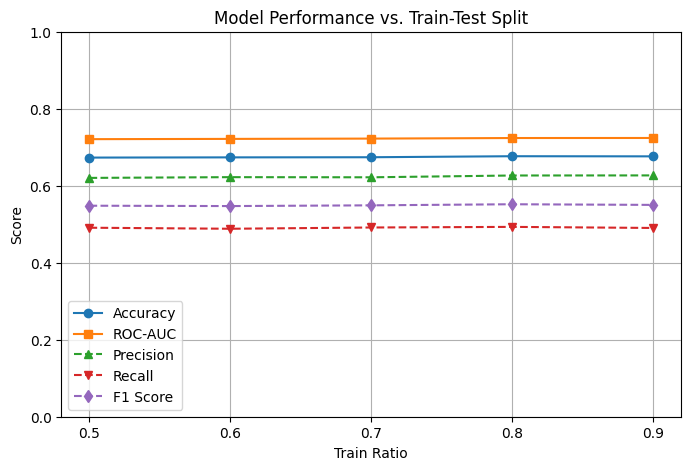

In [69]:
results_df['Train_Ratio'] = results_df['Train_Ratio'].astype(float)
plt.figure(figsize=(8,5))
plt.plot(results_df['Train_Ratio'], results_df['Accuracy'], marker='o', linestyle='-', label='Accuracy')
plt.plot(results_df['Train_Ratio'], results_df['ROC_AUC'], marker='s', linestyle='-', label='ROC-AUC')
plt.plot(results_df['Train_Ratio'], results_df['Precision'], marker='^', linestyle='--', label='Precision')
plt.plot(results_df['Train_Ratio'], results_df['Recall'], marker='v', linestyle='--', label='Recall')
plt.plot(results_df['Train_Ratio'], results_df['F1'], marker='d', linestyle='--', label='F1 Score')

plt.title("Model Performance vs. Train-Test Split")
plt.xlabel("Train Ratio")
plt.ylabel("Score")
plt.xticks(results_df['Train_Ratio'])
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()

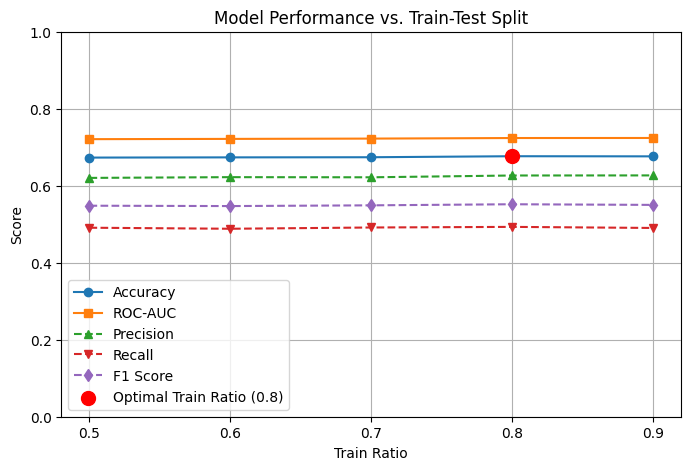

In [70]:
results_df['Train_Ratio'] = results_df['Train_Ratio'].astype(float)
optimal_idx = results_df['Accuracy'].idxmax()
optimal_ratio = results_df.loc[optimal_idx, 'Train_Ratio']
optimal_acc = results_df.loc[optimal_idx, 'Accuracy']

plt.figure(figsize=(8,5))
plt.plot(results_df['Train_Ratio'], results_df['Accuracy'], marker='o', linestyle='-', label='Accuracy')
plt.plot(results_df['Train_Ratio'], results_df['ROC_AUC'], marker='s', linestyle='-', label='ROC-AUC')
plt.plot(results_df['Train_Ratio'], results_df['Precision'], marker='^', linestyle='--', label='Precision')
plt.plot(results_df['Train_Ratio'], results_df['Recall'], marker='v', linestyle='--', label='Recall')
plt.plot(results_df['Train_Ratio'], results_df['F1'], marker='d', linestyle='--', label='F1 Score')

plt.scatter(optimal_ratio, optimal_acc, color='red', s=100, zorder=5, label=f'Optimal Train Ratio ({optimal_ratio})')
plt.title("Model Performance vs. Train-Test Split")
plt.xlabel("Train Ratio")
plt.ylabel("Score")
plt.xticks(results_df['Train_Ratio'])
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()


  0%|          | 0/1000000 [00:00<?, ?it/s]

Learned edges (DAG): [('Category', 'Subcategory_reduced'), ('Category', 'Goal_bin'), ('Category', 'Region'), ('Subcategory_reduced', 'Target'), ('Goal_bin', 'Duration_bin'), ('Target', 'Goal_bin'), ('Target', 'Duration_bin'), ('Target', 'Launch_month_bin')]


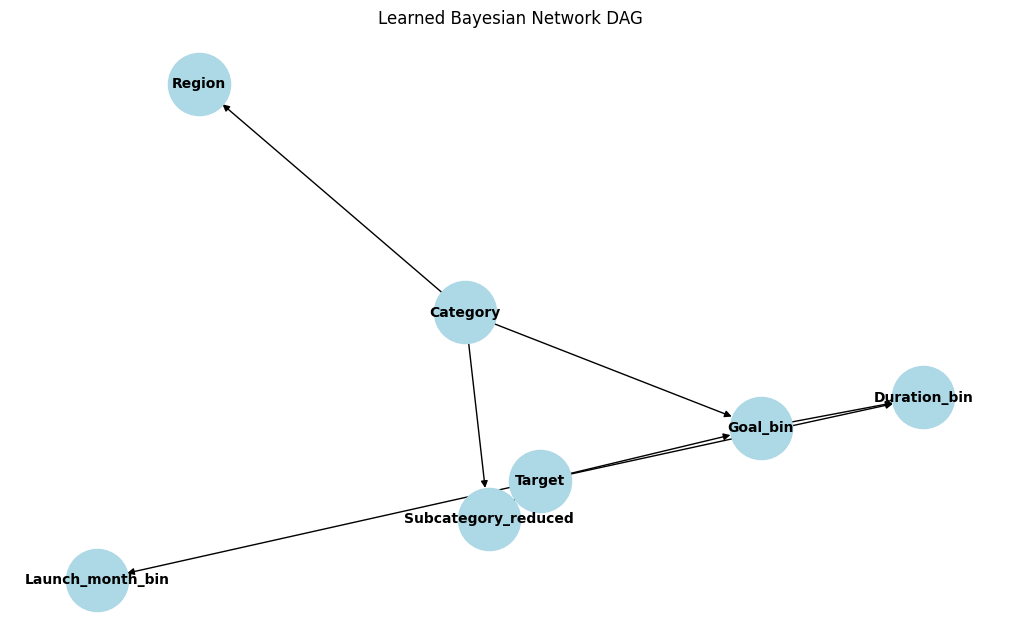


Train ratio 60%:


Evaluating: 100%|██████████| 132585/132585 [01:45<00:00, 1252.80it/s]


Accuracy: 0.6722
Precision: 0.6192
Recall: 0.4888
F1 Score: 0.5464
ROC-AUC: 0.7213


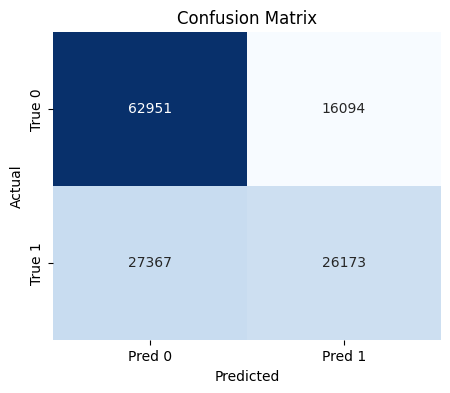


Train ratio 70%:


Evaluating: 100%|██████████| 99439/99439 [01:18<00:00, 1268.38it/s]


Accuracy: 0.6719
Precision: 0.6184
Recall: 0.4894
F1 Score: 0.5464
ROC-AUC: 0.7201


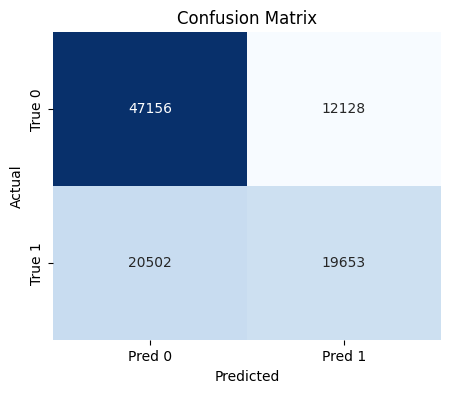


Train ratio 80%:


Evaluating: 100%|██████████| 66293/66293 [00:52<00:00, 1273.72it/s]


Accuracy: 0.6712
Precision: 0.6171
Recall: 0.4892
F1 Score: 0.5458
ROC-AUC: 0.7200


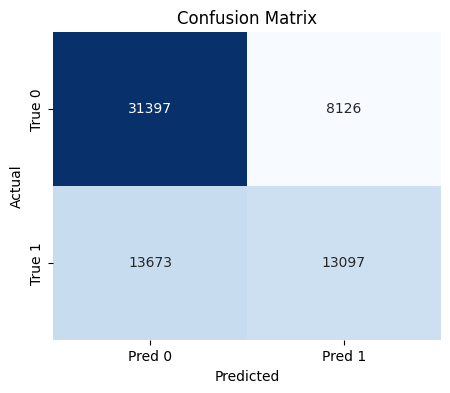


Train ratio 90%:


Evaluating: 100%|██████████| 33147/33147 [00:26<00:00, 1271.20it/s]


Accuracy: 0.6686
Precision: 0.6140
Recall: 0.4829
F1 Score: 0.5406
ROC-AUC: 0.7162


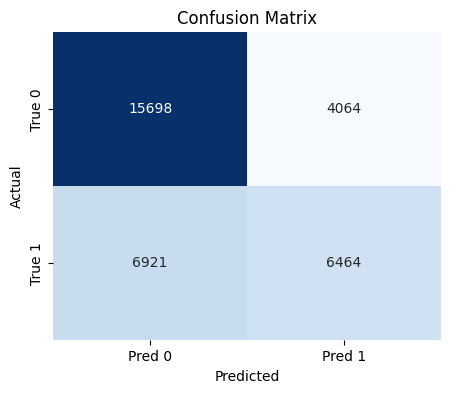

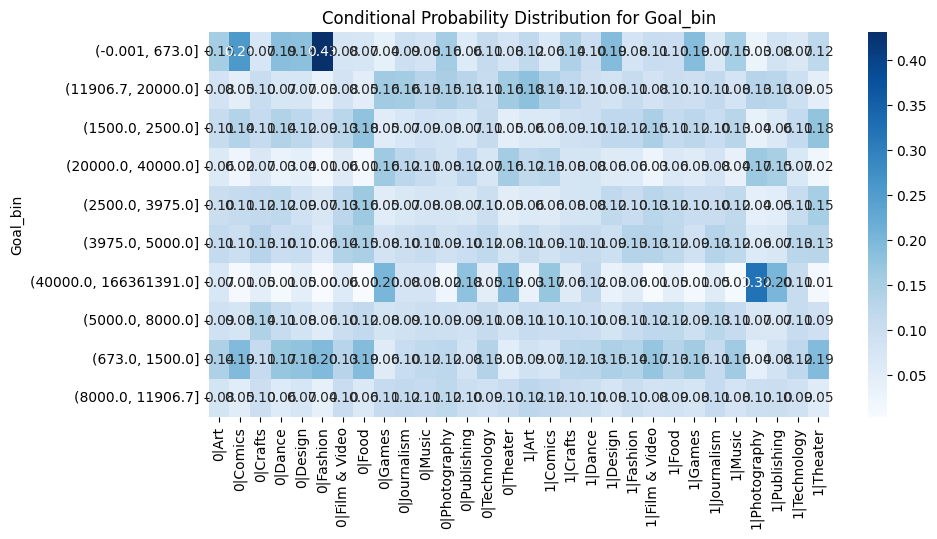

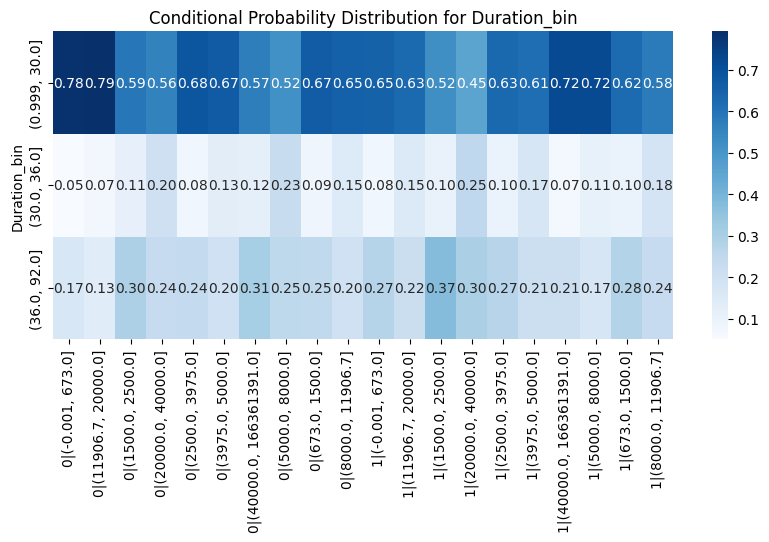

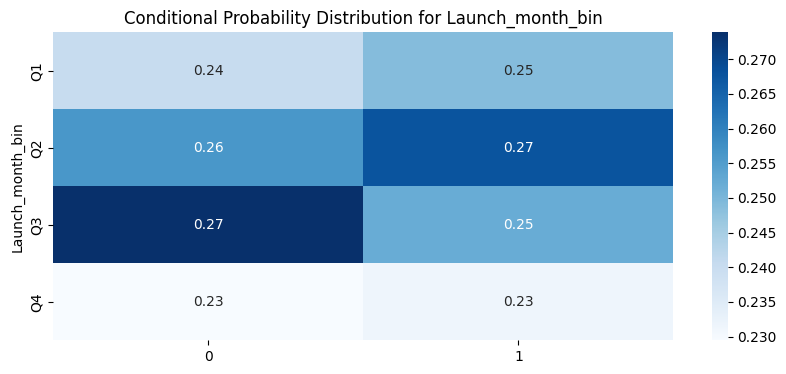

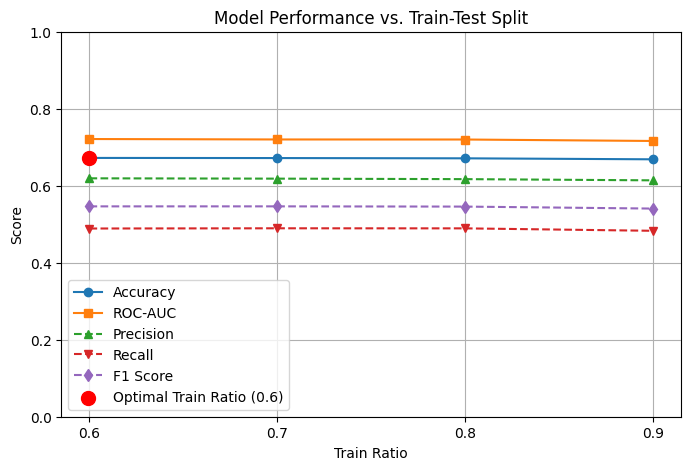


Example prediction: 0.7487347837505934


In [71]:
# --- Patch for pgmpy numpy issue ---
if not hasattr(np, 'product'):
    np.product = np.prod

# --- Parameters ---
sample_for_structure = 100000
required_cols = ['Category', 'Subcategory', 'Region', 'Goal', 'Duration', 'Target', 'Launched']

# --- Validation ---
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")

# --- Feature Engineering / Binning ---
df['Goal_bin'] = pd.qcut(df['Goal'], q=10, duplicates='drop').astype(str)
df['Duration_bin'] = pd.qcut(df['Duration'], q=4, duplicates='drop').astype(str)
df['Launch_month'] = df['Launched'].dt.month
df['Launch_month_bin'] = pd.cut(df['Launch_month'], bins=[0,3,6,9,12],
                                labels=['Q1','Q2','Q3','Q4']).astype(str)
df['Subcategory_reduced'] = df['Subcategory']

# --- Columns for Bayesian Network (remove Goal_per_day) ---
bn_cols = ['Category', 'Subcategory_reduced', 'Region',
           'Goal_bin', 'Duration_bin', 'Launch_month_bin', 'Target']
bn_df = df[bn_cols].dropna().copy()

# --- Structure Learning ---
bn_sample = (bn_df.sample(n=sample_for_structure, random_state=42)
             if len(bn_df) > sample_for_structure else bn_df).reset_index(drop=True)

hc = HillClimbSearch(bn_sample)
best_model = hc.estimate(scoring_method=BicScore(bn_sample))
print("Learned edges (DAG):", best_model.edges())

# --- Visualize DAG ---
G = nx.DiGraph()
G.add_edges_from(best_model.edges())
plt.figure(figsize=(10, 6))
nx.draw(G, with_labels=True, node_size=2000, node_color="lightblue", font_size=10, font_weight="bold")
plt.title("Learned Bayesian Network DAG")
plt.show()

# --- Model Fit ---
model = BayesianNetwork(best_model.edges())
model.fit(bn_df, estimator=BayesianEstimator, prior_type='BDeu', equivalent_sample_size=10)
infer = VariableElimination(model)

# --- Predictor Class ---
class BNBinnedPredictor:
    def __init__(self, model, bn_df):
        self.model = model
        self.infer = VariableElimination(model)
        self.bn_df = bn_df

    def map_to_bin(self, value, column_name):
        bins = self.bn_df[column_name].unique()
        for b in bins:
            try:
                if pd.Interval(left=float(b.split(',')[0][1:]),
                               right=float(b.split(',')[1][:-1])).contains(value):
                    return b
            except Exception:
                if str(value) == b:
                    return b
        return bins[0]

    def prepare_evidence(self, evidence):
        ev = evidence.copy()
        if 'Goal' in ev: ev['Goal_bin'] = self.map_to_bin(ev.pop('Goal'), 'Goal_bin')
        if 'Duration' in ev: ev['Duration_bin'] = self.map_to_bin(ev.pop('Duration'), 'Duration_bin')
        return ev

    def predict_success(self, evidence):
        ev = self.prepare_evidence(evidence)
        try:
            q = self.infer.query(variables=['Target'], evidence=ev, show_progress=False)
            return float(q.values[1])
        except Exception:
            return None

predictor = BNBinnedPredictor(model, bn_df)

# --- Evaluation Function ---
def evaluate_model(train_df, test_df, model, bn_df):
    predictor = BNBinnedPredictor(model, bn_df)
    test_df = test_df.copy()
    probs, preds = [], []
    for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Evaluating"):
        ev = {k: row[k] for k in ['Category','Subcategory_reduced','Region',
                                  'Goal_bin','Duration_bin','Launch_month_bin']}
        p = predictor.predict_success(ev)
        probs.append(p)
        preds.append(int(p >= 0.5 if p is not None else 0))
    test_df['pred_prob'], test_df['pred'] = probs, preds
    y_true, y_pred = test_df['Target'], test_df['pred']

    # --- Numeric Metrics ---
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1 Score: {f1:.4f}")

    try:
        roc_auc = roc_auc_score(y_true, test_df['pred_prob'])
        print(f"ROC-AUC: {roc_auc:.4f}")
    except:
        roc_auc = None
        print("ROC-AUC not computable")

    # --- Confusion Matrix ---
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return acc, prec, rec, f1, roc_auc

# --- Train/Test Evaluation ---
results = []
train_ratios = [0.6, 0.7, 0.8, 0.9]
for r in train_ratios:
    print(f"\nTrain ratio {r:.0%}:")
    train_df, test_df = train_test_split(bn_df, train_size=r, stratify=bn_df['Target'], random_state=42)
    model.fit(train_df, estimator=BayesianEstimator, prior_type='BDeu', equivalent_sample_size=10)
    acc, prec, rec, f1, roc_auc = evaluate_model(train_df, test_df, model, bn_df)
    results.append([r, acc, prec, rec, f1, roc_auc])

# --- Convert results to DataFrame ---
results_df = pd.DataFrame(results, columns=['Train_Ratio','Accuracy','Precision','Recall','F1','ROC_AUC'])

# --- CPD Heatmaps after training ---
for var in ['Goal_bin', 'Duration_bin', 'Launch_month_bin']:
    cpd = model.get_cpds(var)
    values_2d = cpd.get_values().reshape(cpd.get_values().shape[0], -1)
    evidence = cpd.get_evidence()
    if evidence:
        import itertools
        parent_states = [cpd.state_names[p] for p in evidence]
        col_names = ['|'.join(map(str, combo)) for combo in itertools.product(*parent_states)]
    else:
        col_names = cpd.state_names[var]
    df_cpd = pd.DataFrame(values_2d, columns=col_names, index=cpd.state_names[var])
    plt.figure(figsize=(10, max(4, len(cpd.state_names[var])*0.5)))
    sns.heatmap(df_cpd, annot=True, cmap="Blues", cbar=True, fmt=".2f")
    plt.title(f"Conditional Probability Distribution for {var}")
    plt.ylabel(var)
    plt.show()

# --- Aggregate Performance Plot ---
results_df['Train_Ratio'] = results_df['Train_Ratio'].astype(float)
optimal_idx = results_df['Accuracy'].idxmax()
optimal_ratio = results_df.loc[optimal_idx, 'Train_Ratio']
optimal_acc = results_df.loc[optimal_idx, 'Accuracy']

plt.figure(figsize=(8,5))
plt.plot(results_df['Train_Ratio'], results_df['Accuracy'], marker='o', linestyle='-', label='Accuracy')
plt.plot(results_df['Train_Ratio'], results_df['ROC_AUC'], marker='s', linestyle='-', label='ROC-AUC')
plt.plot(results_df['Train_Ratio'], results_df['Precision'], marker='^', linestyle='--', label='Precision')
plt.plot(results_df['Train_Ratio'], results_df['Recall'], marker='v', linestyle='--', label='Recall')
plt.plot(results_df['Train_Ratio'], results_df['F1'], marker='d', linestyle='--', label='F1 Score')
plt.scatter(optimal_ratio, optimal_acc, color='red', s=100, zorder=5, label=f'Optimal Train Ratio ({optimal_ratio})')
plt.title("Model Performance vs. Train-Test Split")
plt.xlabel("Train Ratio")
plt.ylabel("Score")
plt.xticks(results_df['Train_Ratio'])
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()

# --- Example Prediction ---
example = {
    'Category': 'Games',
    'Subcategory_reduced': 'Tabletop Games',
    'Region': 'North America',
    'Goal': 1000, 'Duration': 50,
    'Launch_month_bin': 'Q2'
}
print("\nExample prediction:", predictor.predict_success(example))


# Logistic Regression

/tmp/ipython-input-3891293500.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Subcat_reduced'] = topk_replace(df['Subcategory'].astype(str), TOP_K_SUBCATS)
/tmp/ipython-input-3891293500.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Country_reduced'] = topk_replace(df['Country'].astype(str), TOP_K_COUNTRIES)


Training completed.

Evaluation Metrics:
Accuracy: 0.6639
Precision: 0.6134
Recall: 0.4533
F1: 0.5213
ROC_AUC: 0.7067


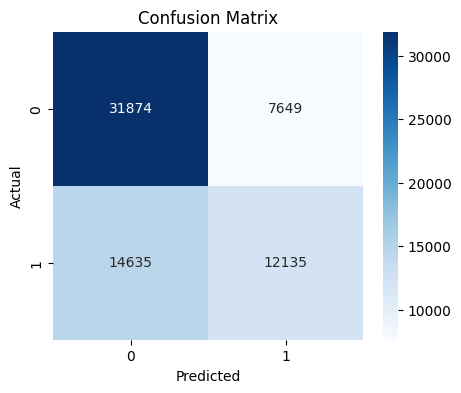

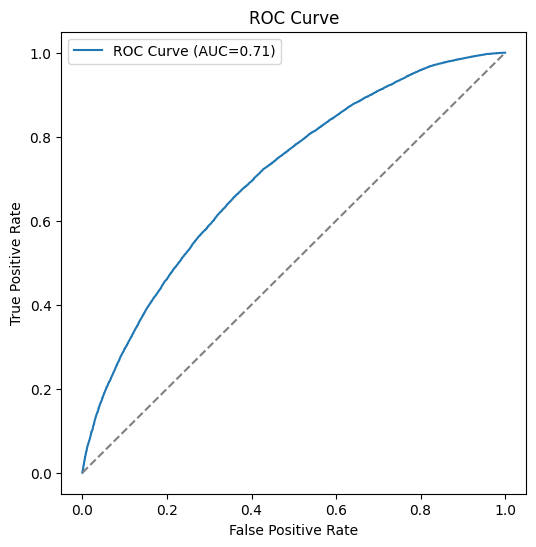


Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.81      0.74     39523
           1       0.61      0.45      0.52     26770

    accuracy                           0.66     66293
   macro avg       0.65      0.63      0.63     66293
weighted avg       0.66      0.66      0.65     66293


Top Coefficients & Odds Ratios:
                           Feature  Coefficient  Odds_Ratio
0    Subcat_reduced_Tabletop Games     2.053623    7.796097
1     Subcat_reduced_Playing Cards     1.271467    3.566081
2                  Category_Comics     0.838238    2.312289
3                 Category_Theater     0.805854    2.238607
4   Subcat_reduced_Classical Music     0.731560    2.078321
5            Subcat_reduced_Shorts     0.696023    2.005759
6                   Category_Dance     0.695923    2.005559
7        Subcat_reduced_Indie Rock     0.695849    2.005411
8    Subcat_reduced_Country & Folk     0.673788    1.961654
9             S

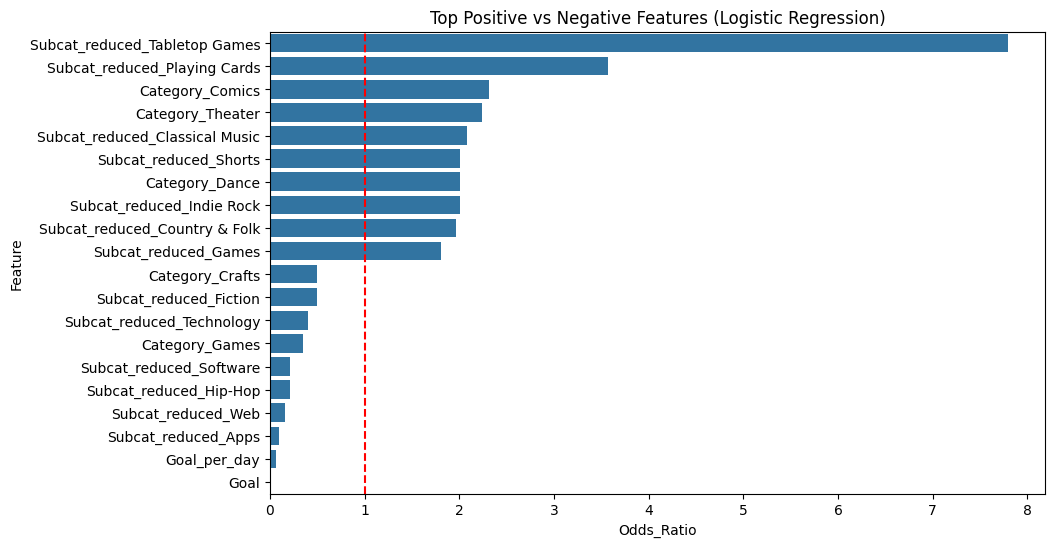


Logit Equation:
 logit(p) = -0.9411 + (-14.3251 * Goal) + (-0.2260 * Duration) + (-2.7326 * Goal_per_day) + (-0.0822 * Category_Art) + (0.8382 * Category_Comics) + (-0.6984 * Category_Crafts) + (0.6959 * Category_Dance) + (-0.0247 * Category_Design) + (-0.5173 * Category_Fashion) + (-0.1198 * Category_Film & Video) + (-0.6085 * Category_Food) + (-1.0394 * Category_Games) + (-0.4058 * Category_Journalism) + (0.2879 * Category_Music) + (-0.3418 * Category_Photography) + (-0.0309 * Category_Publishing) + (0.3472 * Category_Technology) + (0.8059 * Category_Theater) + (0.4069 * Subcat_reduced_Accessories) + (-0.2372 * Subcat_reduced_Animation) + (-0.4013 * Subcat_reduced_Apparel) + (-2.3645 * Subcat_reduced_Apps) + (0.1491 * Subcat_reduced_Art) + (0.5162 * Subcat_reduced_Art Books) + (-0.1962 * Subcat_reduced_Children's Books) + (0.7316 * Subcat_reduced_Classical Music) + (0.1267 * Subcat_reduced_Comedy) + (-0.0234 * Subcat_reduced_Comic Books) + (-0.3696 * Subcat_reduced_Comics) + (0.6738

In [73]:
numeric_features = ['Goal', 'Duration']
if 'Goal_per_day' in df.columns:
    numeric_features.append('Goal_per_day')

TOP_K_SUBCATS = 50
TOP_K_COUNTRIES = 30

def topk_replace(series, k):
    topk = series.value_counts().index[:k]
    return series.where(series.isin(topk), other='Other')

df['Subcat_reduced'] = topk_replace(df['Subcategory'].astype(str), TOP_K_SUBCATS)
df['Country_reduced'] = topk_replace(df['Country'].astype(str), TOP_K_COUNTRIES)

categorical_features = ['Category', 'Subcat_reduced', 'Country_reduced']

df = df.dropna(subset=numeric_features + categorical_features + ['Target']).reset_index(drop=True)

X = df[numeric_features + categorical_features]
y = df['Target'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

pipeline = Pipeline([
    ('preproc', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, solver='lbfgs'))
])

pipeline.fit(X_train, y_train)
print("Training completed.")

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'ROC_AUC': roc_auc_score(y_test, y_proba)
}

print("\nEvaluation Metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC={roc_auc_score(y_test, y_proba):.2f})')
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

print("\nClassification Report:\n", classification_report(y_test, y_pred))

clf = pipeline.named_steps['clf']
feature_names = (
    numeric_features +
    list(pipeline.named_steps['preproc'].named_transformers_['cat'].get_feature_names_out(categorical_features))
)

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': clf.coef_[0],
    'Odds_Ratio': np.exp(clf.coef_[0])
}).sort_values(by='Coefficient', ascending=False).reset_index(drop=True)

print("\nTop Coefficients & Odds Ratios:")
print(coef_df.head(20))

top_pos = coef_df.head(10)
top_neg = coef_df.tail(10)

plt.figure(figsize=(10,6))
sns.barplot(x='Odds_Ratio', y='Feature', data=pd.concat([top_pos, top_neg]))
plt.axvline(x=1, color='red', linestyle='--')
plt.title('Top Positive vs Negative Features (Logistic Regression)')
plt.show()

intercept = clf.intercept_[0]
terms = [f"({coef:.4f} * {feat})" for coef, feat in zip(clf.coef_[0], feature_names)]

logit_eq = f"logit(p) = {intercept:.4f} + " + " + ".join(terms)
prob_eq = f"p = 1 / (1 + exp(-({intercept:.4f} + " + " + ".join(terms) + ")))"

print("\nLogit Equation:\n", logit_eq)
print("\nProbability Equation:\n", prob_eq)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



Training & evaluating: Logistic_L2


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Metrics: {'fit_time_s': 322.39828419685364, 'Accuracy': 0.6586819121174181, 'Precision': 0.6159659631640821, 'Recall': 0.4110197982816586, 'F1': 0.4930432639526808, 'ROC_AUC': np.float64(0.6988077732639726)}

Training & evaluating: RandomForest
Metrics: {'fit_time_s': 100.41184759140015, 'Accuracy': 0.6695277027740485, 'Precision': 0.6507316468253969, 'Recall': 0.3920433320881584, 'F1': 0.4893002004755466, 'ROC_AUC': np.float64(0.7217863680913383)}

Best model by ROC_AUC: RandomForest


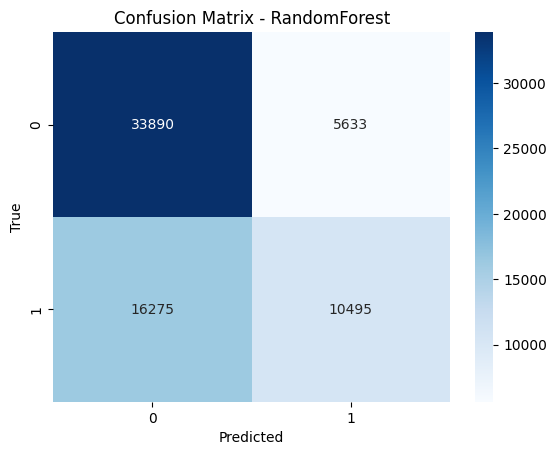


Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.86      0.76     39523
           1       0.65      0.39      0.49     26770

    accuracy                           0.67     66293
   macro avg       0.66      0.62      0.62     66293
weighted avg       0.67      0.67      0.65     66293



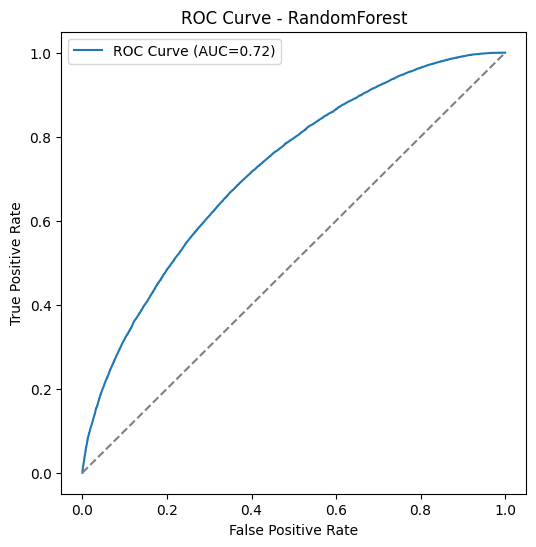

,Pred_Probability,Pred_Label
202916,0.375322,0
277792,0.203808,0
299260,0.388250,0
254216,0.381964,0
302789,0.378734,0


In [76]:
RANDOM_STATE = 42
MAX_LOGIT_ITER = 500
N_JOBS = -1
TOP_K_SUBCATS = 50
TOP_K_COUNTRIES = 30
N_FEATURES_SELECT = 200
TEST_SIZE = 0.2

numeric_features = [c for c in ['Goal', 'Duration', 'Goal_per_day'] if c in df.columns]

def topk_replace(series, k):
    topk = series.value_counts().index[:k]
    return series.where(series.isin(topk), 'Other')

if 'Subcategory' in df.columns:
    df['Subcat_reduced'] = topk_replace(df['Subcategory'].astype(str), TOP_K_SUBCATS)
if 'Country' in df.columns:
    df['Country_reduced'] = topk_replace(df['Country'].astype(str), TOP_K_COUNTRIES)

categorical_features = []
if 'Subcat_reduced' in df.columns:
    categorical_features.append('Subcat_reduced')
if 'Country_reduced' in df.columns:
    categorical_features.append('Country_reduced')
if 'Category' in df.columns:
    categorical_features.append('Category')

df = df.dropna(subset=numeric_features + categorical_features + ['Target']).reset_index(drop=True)

X = df[numeric_features + categorical_features]
y = df['Target'].astype(int)
X, y = shuffle(X, y, random_state=RANDOM_STATE)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE,
                                                    random_state=RANDOM_STATE,
                                                    stratify=y)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

sel_logit = Pipeline([
    ('preproc', preprocessor),
    ('clf', LogisticRegression(C=0.5, penalty='l1', solver='saga',
                               max_iter=MAX_LOGIT_ITER, n_jobs=N_JOBS,
                               random_state=RANDOM_STATE))
])
sel_logit.fit(X_train, y_train)

X_train_trans = sel_logit.named_steps['preproc'].transform(X_train)
coef = sel_logit.named_steps['clf'].coef_.ravel()

num_names = numeric_features
cat_names = list(sel_logit.named_steps['preproc'].named_transformers_['cat'].get_feature_names_out(categorical_features))
all_features = num_names + cat_names

top_idx = np.argsort(np.abs(coef))[::-1][:N_FEATURES_SELECT]

selected_features = [all_features[i] for i in top_idx]

class SelectEncodedFeatures(TransformerMixin, BaseEstimator):
    def __init__(self, selected_idx):
        self.selected_idx = np.array(selected_idx)
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        if hasattr(X, "tocsc"):
            return X[:, self.selected_idx]
        return X[:, self.selected_idx]

select_transform = SelectEncodedFeatures(selected_idx=top_idx)

logit_final = Pipeline([
    ('preproc', preprocessor),
    ('select', select_transform),
    ('clf', LogisticRegression(C=1.0, penalty='l2', solver='saga',
                               max_iter=MAX_LOGIT_ITER, n_jobs=N_JOBS,
                               random_state=RANDOM_STATE))
])

rf_final = Pipeline([
    ('preproc', preprocessor),
    ('select', select_transform),
    ('clf', RandomForestClassifier(n_estimators=300, max_depth=15,
                                   n_jobs=N_JOBS, random_state=RANDOM_STATE))
])

models = {'Logistic_L2': logit_final, 'RandomForest': rf_final}

def evaluate_model(pipe, X_tr, y_tr, X_te, y_te):
    t0 = time.time()
    pipe.fit(X_tr, y_tr)
    t1 = time.time()
    preds_proba = pipe.predict_proba(X_te)[:,1]
    preds = (preds_proba >= 0.5).astype(int)
    metrics = {
        'fit_time_s': t1 - t0,
        'Accuracy': accuracy_score(y_te, preds),
        'Precision': precision_score(y_te, preds, zero_division=0),
        'Recall': recall_score(y_te, preds, zero_division=0),
        'F1': f1_score(y_te, preds, zero_division=0),
        'ROC_AUC': roc_auc_score(y_te, preds_proba)
    }
    return metrics, preds_proba, preds

results = {}
for name, pipe in models.items():
    print(f"\nTraining & evaluating: {name}")
    metrics, preds_proba, preds = evaluate_model(pipe, X_train, y_train, X_test, y_test)
    results[name] = metrics
    print("Metrics:", metrics)

results_df = pd.DataFrame(results).T
best_model_name = results_df['ROC_AUC'].idxmax()
print("\nBest model by ROC_AUC:", best_model_name)
best_pipeline = models[best_model_name]

best_metrics, best_proba, best_pred = evaluate_model(best_pipeline, X_train, y_train, X_test, y_test)
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

print("\nClassification Report:\n", classification_report(y_test, best_pred, zero_division=0))

fpr, tpr, _ = roc_curve(y_test, best_proba)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC={roc_auc_score(y_test, best_proba):.2f})")
plt.plot([0,1],[0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - {best_model_name}")
plt.legend()
plt.show()

if 'Logistic' in best_model_name:
    clf = best_pipeline.named_steps['clf']
    sel_idx = best_pipeline.named_steps['select'].selected_idx
    feat_names = all_features
    sel_names = [feat_names[i] for i in sel_idx]
    coefs = clf.coef_.ravel()
    intercept = clf.intercept_[0]

    coef_df = pd.DataFrame({'Feature': sel_names, 'Coefficient': coefs, 'Odds_Ratio': np.exp(coefs)})
    coef_df = coef_df.sort_values(by='Coefficient', ascending=False).reset_index(drop=True)
    print("\nTop Logistic Regression Coefficients & Odds Ratios:")
    print(coef_df.head(20))
    terms = [f"({coef:.4f} * {feat})" for coef, feat in zip(coefs, sel_names)]
    logit_eq = f"logit(p) = {intercept:.4f} + " + " + ".join(terms)
    prob_eq = f"p = 1 / (1 + exp(-({intercept:.4f} + " + " + ".join(terms) + ")))"
    print("\nLogit Equation:\n", logit_eq)
    print("\nProbability Equation:\n", prob_eq)

forecast = X_test.copy()
forecast['Pred_Probability'] = best_pipeline.predict_proba(forecast)[:,1]
forecast['Pred_Label'] = best_pipeline.predict(forecast)
forecast[['Pred_Probability','Pred_Label']].head()